## Import Statements and installations

In [ ]:
from google.colab import files
import os # Define the files to be deleted and modified in google Colab
import shutil # Define the files to be deleted and modified in google Colab
import zipfile # Define the files to be deleted and modified in google Colab
from datetime import datetime #for date saving in file names.
from pytz import timezone
import pytz

## Global Variables

In [ ]:
DEBUG = False #Used if need output from from methods for some methods.
PROCESS_SINGLE_AUTHOR = False # Used for testing purpose. When True then have to upload zip file of single author.
DISPLAY_CHARTS = False #when false then only will save the charts not show in colab.
tz_Berlin = pytz.timezone('Europe/Berlin') #Berlin time when saving date in the filename of xlsx
global CURRENT_DATE
CURRENT_DATE = datetime.now(tz_Berlin).strftime('%d%b%Y')  # for folder path wrt date


global network_list_Wertungen

global network_list_Relationen

global network_list_Wertungen_und_Relationen

global DOCUMENT_LIST_RELATIONEN
global DOCUMENT_LIST_WERTUNGEN
global DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN

DOCUMENT_LIST_RELATIONEN = []
DOCUMENT_LIST_WERTUNGEN = []
DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN = []


# Common Functions

### Fuction to delete all files

In [ ]:
def action_delete_all_files(directory):
  '''
  Delete all files.
  '''
  try:
      # Check if the directory exists
      if os.path.exists(directory) and os.path.isdir(directory):
          # Iterate over all files and directories within the directory
          for filename in os.listdir(directory):
              file_path = os.path.join(directory, filename)

              # Check if it's a file and delete it
              if os.path.isfile(file_path) or os.path.islink(file_path):
                  os.remove(file_path)
                  print(f"Deleted file: {file_path}")
              # Check if it's a directory (optional) and skip or delete recursively
              elif os.path.isdir(file_path):
                  shutil.rmtree(file_path)  # Use this if you want to delete subdirectories
                  print(f"Deleted directory: {file_path}")
      else:
          print("Directory does not exist or is not a directory.")
  except Exception as e:
      print(f"Error while deleting files: {e}")

### Function to upload just single author .zip

In [ ]:
#Upload zip file intcontaining CAS XMI and XML
def upload_next_author_zip():

  #First delete files of previous author, if any.
  # Define the files to be deleted
  files_to_delete = ['TypeSystem.xml', 'CURATION_USER.xmi']

  # Path to the folder where the files are located
  content_folder_path = '/content/'

  # Delete the specified files if they exist
  for file_name in files_to_delete:
      file_path = os.path.join(content_folder_path, file_name)
      if os.path.isfile(file_path):
          os.remove(file_path)
          print(f"Deleted {file_path}")
      else:
          print(f"File {file_path} does not exist.")

  print(f"Deletion process completed for {files_to_delete} from path: {content_folder_path}.")
  print("\n")

  #Upload the ZIP file
  uploaded = files.upload()

  # Specify the extraction path
  content_folder_path = '/content/'

  # Extract the uploaded ZIP file to the specified folder
  for filename in uploaded.keys():
      # Ensure it's a zip file
      if filename.endswith('.zip'):
          with zipfile.ZipFile(filename, 'r') as zip_ref:
              zip_ref.extractall(content_folder_path)
              print(f'Extracted all files from {filename} to {content_folder_path}')
      else:
          print(f'{filename} is not a zip file')

  # Delete the ZIP file after extraction
  os.remove(filename)
  print(f'Deleted the ZIP file: {filename}')

### Functions of uploading zip file for all authors and extracting zip files and retun the list of folders.

In [ ]:
#Extract files from from zip. for all authors "webanno*****export_curated_documents.zip"
def extract_nested_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as main_zip:
        # Extract the main zip
        main_zip.extractall(extract_to)

        # Iterate through each folder in the curation directory
        for folder_name in main_zip.namelist():
            if folder_name.endswith('.zip') and 'curation' in folder_name:
                nested_zip_path = os.path.join(extract_to, folder_name)

                # Extract the nested zip files
                with zipfile.ZipFile(nested_zip_path, 'r') as nested_zip:
                    nested_zip.extractall(os.path.dirname(nested_zip_path))

#returns the folder names as list in './curation'.
def get_folder_names(curation_path='./curation'):
    folder_names = [folder_name for folder_name in os.listdir(curation_path)
                    if os.path.isdir(os.path.join(curation_path, folder_name))]
    return folder_names



### Funtion to get metadata from the xmi file

In [ ]:
#Gets Title from Metadata.
#Requires: CAS_XMI file
#Retuns: document_title from metadata
def document_metadata_info(typesystem_xml, doc_CAS_xmi, debug = False):
  # Get the DocumentMetaData type from the type system
  DocumentMetaData = typesystem_xml.get_type('de.tudarmstadt.ukp.dkpro.core.api.metadata.type.DocumentMetaData')
  # Retrieve the DocumentMetaData from the CAS Doc
  document_metadata_list = doc_CAS_xmi.select(DocumentMetaData)

  # Metadata list
  if document_metadata_list:
      document_metadata = document_metadata_list[0] # Access the first (and only) item in the list
      document_title = document_metadata.documentTitle  #Document Title

 #Calculated values from this cell.
  if debug:
    print("#################### DocumentMetaData #####################################")
    print(document_metadata_list)

  return document_title

# Daten Für Netzwerkanalysen generieren

In [ ]:
!pip install dkpro-cassis
#!pip install spacy-sentiws
#!python -m spacy download de_core_news_sm
from cassis import *
from pathlib import *
import pprint

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 52.7 MB/s eta 0:00:00
  Attempting uninstall: lxml
    Found existing installation: lxml 5.4.0
    Uninstalling lxml-5.4.0:
      Successfully uninstalled lxml-5.4.0


### x Relationen

In [ ]:
def xRelationen(doc_CAS_xmi, exclude_self_evaluations ,debug = False):

  # Relationen ausgeben
  n= 0
  Relationen = {}
  for segment in doc_CAS_xmi.select('custom.Relation'):
      n = n+1

      if(debug):
        print("#################### Relationen #####################################")
        #print(segment)
        print(n, ". Relation: ", segment.label) # Natürlich-kulturell-Opposition oder Wertopposition
        print(segment.Governor.get_covered_text(), segment.Governor.label, segment.Governor.Name)
        print(segment.Dependent.get_covered_text(), segment.Dependent.label, segment.Dependent.Name)
        print("\n")
      if segment.Governor.Name is not None:
          Source = segment.Governor.Name.rsplit(": ")[1]
      else:
          Source = segment.Governor.get_covered_text()

      if segment.Dependent.Name is not None:
          Target = segment.Dependent.Name.rsplit(": ")[1]
      else:
          Target = segment.Dependent.get_covered_text()

      if (exclude_self_evaluations and Source==Target):  #17-11-24 remove self evaluations
        pass
      else:
        Relationen[n] = Source, Target, segment.label

  if(debug):
    print("Function Returns::::::: Relationen::::::")
    print(Relationen)
  return Relationen

### x Codierungen

In [ ]:
def polarität_zu_int(polarität):
  """
  Gibt für verschiedene Codierungspolaritäten Integer aus, um Kompatibilität mit bisherigen Code (auf Wertungen bezogen) zu gewährleisten.

  Bsp: polarität == "sehr alt/traditionell" returns -1
  """
  match polarität:
    case "sehr althergebracht/traditionell" | "sehr alt/traditionell" | "sehr flach/oberflächlich" | "sehr kulturell/zivilisatorisch" | "sehr disharmonisch/fragmentiert" | "sehr krank/morbid":
      return -1
    case "althergebracht/traditionell" | "alt/traditionell" | "flach/oberflächlich" | "kulturell/zivilisatorisch" | "disharmonisch/fragmentiert" | "krank/morbid":
      return -1
    case "neuartig/modern" | "tief/tiefsinnig" | "natürlich/ursprünglich" | "harmonisch/ganzheitlich" | "gesund/heil":
      return 1
    case "sehr neuartig/modern" | "sehr tief/tiefsinnig" | "sehr natürlich/ursprünglich" | "sehr harmonisch/ganzheitlich" | "sehr gesund/heil":
      return 1
    case _:
      raise ValueError("Keine existierende Polarität: %s", polarität)


In [ ]:
def xCodierungen(doc_CAS_xmi,debug=False):
  # Codierungen auslesen
  Codierungen = {}
  j = 0
  # speichert Codierungen nach diesem Muster (analog dazu, wie Wertungen abgespeichert werden):
  # {1: (Codierende*r, codierte Entität, Art der Codierung, Polarität, Entitätentyp),
  #  2: (Codierende*r, codierte Entität, Art der Codierung, Polarität, Entitätentyp)}

  # ein segment == eine codierung
  for segment in doc_CAS_xmi.select('webanno.custom.AltNeuCodierung'):

      j = j+1
      #print(segment.get_covered_text())
      if segment.Polaritt_harmonisch:
        # polarität = segment.Polaritt_harmonisch # polarität als string abspeichern (zB "sehr alt/traditionell" statt -1)
        polarität = polarität_zu_int(segment.Polaritt_harmonisch)
      elif segment.Polaritt_gesund:
        # polarität = segment.Polaritt_gesund
        polarität = polarität_zu_int(segment.Polaritt_gesund)
      elif segment.Polaritt_natrlich:
        # polarität = segment.Polaritt_natrlich
        polarität = polarität_zu_int(segment.Polaritt_natrlich)
      elif segment.Polaritt_tief:
        # polarität = segment.Polaritt_tief
        polarität = polarität_zu_int(segment.Polaritt_tief)
      elif segment.Polaritt:
        # polarität = segment.Polaritt
        polarität = polarität_zu_int(segment.Polaritt)
      else:
        # polarität = None
        polarität = polarität_zu_int(None)

      codierte_entität = ""
      codierend = "Erzähler" # default Codierende*r ist Erzähler*in
      if segment.Bezugsentitt: # d.h. wir ignorieren all jene Codierungen, bei denen keine codierte Entität o Codierende*r annotiert ist (weil schlecht darstellbar). Bei zB Roth werden dann zwei Codierungen nicht weiter berücksichtigt
        for e in segment.Bezugsentitt.elements:
            if e.role == "codierte Entität":
              ent_typ = e.target.label
              if e.target.Name:
                codierte_entität = e.target.Name.split(":")[1].strip()
              else:
                codierte_entität = e.target.get_covered_text()
            elif e.role == "Codierender": # wenn die Entität Codierender ist und nicht Codierter (gibts z.B. bei Roth)
              if e.target.Name:
                codierend = e.target.Name.split(":")[1].strip()
              else:
                codierend = e.target.get_covered_text()
        """
        # kompaktere Speicherungsart:
        # {codierte Entität A : [[Art der Codierung, Polarität, Codierende*r], [Art der Codierung2, Polarität2, Codierende*r2], ...]; codierte Entität B: []; ...}
        if codierte_entität in Codierungen: # wenn diese Entität bereits als key existiert, weil schon andere Codierung dazu abgespeichert wurde
          Codierungen[codierte_entität].append([segment.Art, polarität, codierend, ent_typ])
        else:
          Codierungen[codierte_entität] = [[segment.Art, polarität, codierend, ent_typ]]
        """
        if codierte_entität:
          Codierungen[j] = codierend, codierte_entität, segment.Art, polarität, ent_typ

  # testweise Ausgabe
  if(debug):
    print("======Codierungen:::::::::")
    for k,v in Codierungen.items():
      print(k, ": ", v)
  return Codierungen, j

### x Wertungen

In [ ]:
#used in xWertungen
def xErzhlerwechsel(doc_CAS_xmi,debug=False):
  #All names, begin and end of Erzhlerwechsel
  Erzhlerwechsel_dict = {}
  index=0
  for segment in doc_CAS_xmi.select('webanno.custom.Erzhlerwechsel'):
    narrator_name = segment.NamedesneuenErzhlers.rsplit(": ")[1]
    Erzhlerwechsel_dict[index] = narrator_name,segment.begin, segment.end
    index+=1

  if (debug):
    print("xErzhlerwechsel:",Erzhlerwechsel_dict)

  return Erzhlerwechsel_dict

In [ ]:
def xWertungen(doc_CAS_xmi,j, Erzhlerwechsel_dict, exclude_self_evaluations,debug=False):

  (default_name, default_begin, default_end) = Erzhlerwechsel_dict[0]  # First entry as default
  total_Erzhlerwechsel = len(Erzhlerwechsel_dict)
  next_Erzhlerwechsel = 1

  j=0

  Wertungen = {}
  i=j # Nummerierung der Wertungen (= keys vom Wertungen-Dictionary) beginnt da, wo diejenige der Codierungen aufhört, sodass beide dictionaries
  # sich, wenn geüwnscht, mergen lassen und zusammen im Netzwerk darstellen lassen
  # s.u: Codierungen und/oder Wertungen anzeigen?

  # implement registration of "Erzählerwechsel" here to adopt default for "Wertender" below



  for segment in doc_CAS_xmi.select('webanno.custom.Wertung'):

      # Check if we are within bounds and update the default name based on segment's begin
      if next_Erzhlerwechsel < total_Erzhlerwechsel:
          (next_name, next_begin, next_end) = Erzhlerwechsel_dict[next_Erzhlerwechsel]
          if segment.begin >= next_begin:
              default_name = next_name
              next_Erzhlerwechsel += 1

      Wertender = default_name # default


      gew_Ent = None # default

      i = i+1

      #print(segment.TEST)
      #print(str(segment.TEST.elements))
      #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)
      #if segment.Label == "implizite Wertung" or "explizite Wertung":
      Hinsicht = segment.Wertungshinsicht
      Polarität = segment.Polaritt
      Ironie = segment.Ironie

      if Polarität == "sehr positiv":
          Polarität_int = 1
      if Polarität == "positiv":
          Polarität_int = 1
      if Polarität == "sehr negativ":
          Polarität_int = -1
      if Polarität == "negativ":
          Polarität_int = -1

      # Wertung umkehren wenn Ironie vorhanden
      if Ironie == True:
          Polarität_int = -Polarität_int

      try:
          for e in segment.TEST.elements:
              t= "test"
      except:
          if(debug):
            print("Segment ohne gew. Objekt")
          continue

      for e in segment.TEST.elements:

          if e.role == "Wertender":

              #print(e.role, ": ", e.target.get_covered_text(), "Typ: ", e.target.label, "Name: ", e.target.Name)
              if e.target.Name is not None:
                  Wertender = e.target.Name.rsplit(": ")[1]
              else:
                  Wertender = e.target.get_covered_text()

          if e.role == "gewertete Entität":
                  EntTyp = e.target.label
                  if e.target.Name is not None:
                      gew_Ent = e.target.Name.rsplit(": ")[1]
                  else:
                      gew_Ent = e.target.get_covered_text()

      # Wertung auf Kompositionsebene
      if segment.Wertung_auf_Kompositionsebene == 'Kompositionsebene':
        Wertender = "Autor"

      # Ausschluss von Fällen ohne Wertungsobjekt
      if(exclude_self_evaluations) and (Wertender == gew_Ent): #17-11-24 remove self evaluations
          pass
      elif gew_Ent is not None:
        if (Hinsicht=="eudämonistisch"):
          if not (EntTyp=="FIGUR" or EntTyp=="FIGURENGRUPPE"): #17-11-24: Exluded all eudämonistisch evaluation for FIGUR and FIGURENGRUPPE
            Wertungen[i] = Wertender, gew_Ent, Hinsicht, Polarität_int, EntTyp
        else:
          Wertungen[i] = Wertender, gew_Ent, Hinsicht, Polarität_int, EntTyp
  if(debug):
    print("====== Wertungen ::::::::::")
    for i, _wertungen in Wertungen.items():
      print(i,Wertungen)

  return Wertungen, i

### x Positive und negativ bewertete Entitäten

In [ ]:
def xPositive_und_negativ_bewertete_Entitäten(Wertungen,debug=False):
  """
  Ent_Bewert speichert zu jeder bewerteten Entität ab, in welcher Hinsicht und mit welcher Polarität die bewertet wird,
  nach folgendem Muster (Beispiel):

  {'der Einsamkeit': {'ästhetisch': 0.5,
    'epistemisch': 0,
    'eudämonistisch': -0.5,
    'eudämonistisch Figur': 0,
    'moralisch': 0,
    'sozialer Status': 0,
    'sonstige': 0,
    'nicht spezifiziert': 0,
    'gesamt': 0.0,
    'gesamt_Erzähler': 0.0,
    'gesamt_Rest': 0,
    'Typ Entität': 'ABSTRAKTUM'}, ...}
  """

  Id = 0
  Ent_Bewert = {}

  keylist = ["ästhetisch", "epistemisch", "eudämonistisch", "eudämonistisch Figur", "moralisch",
                            "sozialer Status", "sonstige", "nicht spezifiziert", "gesamt", "gesamt_Erzähler", "gesamt_Rest", "Typ Entität"]

  for key, value in Wertungen.items():
      Wertender = value[0]
      Entität = value[1]
      Hinsicht = value[2]
      Polarität = value[3]
      EntTyp = value[4]
      #print(Wertungen.items())



      #if Wertender == "Erzähler":            #optional nur Erzählerwertungen
      if Entität in Ent_Bewert.keys():
          Ent_Bewert[Entität][Hinsicht] = Ent_Bewert[Entität][Hinsicht] + Polarität
          Ent_Bewert[Entität]["gesamt"] += Polarität
          if Wertender == "Erzähler":
            try:
              Ent_Bewert[Entität]["gesamt_Erzähler"] = Ent_Bewert[Entität]["gesamt_Erzähler"] + Polarität
            except KeyError: # falls gesamt_Erzähler noch nicht initialisiert wurde
              Ent_Bewert[Entität]["gesamt_Erzähler"] = Polarität
          else: # Wertungen, die nicht vom Erzähler ausgehen
            try:
              Ent_Bewert[Entität]["gesamt_Rest"] = Ent_Bewert[Entität]["gesamt_Rest"] + Polarität
            except KeyError:
              Ent_Bewert[Entität]["gesamt_Rest"] = Polarität
      else: # wenn die entität noch nicht in Ent_Bewert ist
          empty_d = {}
          for i in keylist:
              try:
                empty_d[i] = 0
              except:
                continue
          Ent_Bewert[Entität] = empty_d
          Ent_Bewert[Entität][Hinsicht] = Polarität
          Ent_Bewert[Entität]["gesamt"] = Polarität
          if Wertender == "Erzähler":
            Ent_Bewert[Entität]["gesamt_Erzähler"] = Polarität
          else:
            Ent_Bewert[Entität]["gesamt_Rest"] = Polarität
          Ent_Bewert[Entität]["Typ Entität"] = EntTyp

  if(debug):
    print('xPositive_und_negativ_bewertete_Entitäten::::::::::::::::::')
    print(Ent_Bewert)
  return Ent_Bewert

# Netzwerkanalyse

In [ ]:
!pip install pyvis
!pip install cyjupyter
!pip install networkx

from pyvis.network import Network
from IPython.display import HTML
import pandas as pd
import networkx as nx
from collections import defaultdict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 16.3 MB/s eta 0:00:00


## Wertungen und Oppositionen als Kanten

In [ ]:
#convert nicht spezifiziert to sonstige in evaluations.
def nichtspezifiziert_to_sonstige(Wertungen):
  for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
    if eval_type == "nicht spezifiziert":
      Wertungen[key] = source, target, "sonstige", eval_value, ent_type
  return Wertungen

In [ ]:
#convertion of labels/types of opposition to encoding oppositions. for complete and split networks
def change_opposition_label(Relationen_german):
  new_dic_oppositions_ger = {
    "Alt-Neu-Opposition": "Codierung Opposition",
    "Wertopposition":"Value Opposition",
    "Traditionell-Modern-Opposition":"Codierung Opposition",
    "Harmonisch-disharmonisch-Opposition":	"Codierung Opposition",
    "Natürlich-kulturell-Opposition":"Codierung Opposition",
    "Gesund-krank-Opposition":"Codierung Opposition",
    "Tief-oberflächlich-Opposition":	"Codierung Opposition",
    "Sonstige Merkmalsopposition":"Feature Opposition",
    "Zugehörigkeit"	:"Belonging to",
    "Element von": "Element of",
    "Encoding Opposition": "Codierung Opposition"
  }

  # Create a new dictionary
  Relationen_new= {}


  for key, (source, target, opposition_type) in list(Relationen_german.items()):

    source = source
    target = target

    # Check if opposition_type exists in dic_German_English
    if opposition_type in new_dic_oppositions_ger:
        # Replace opposition_type with its English translation
        opposition_type_x = new_dic_oppositions_ger[opposition_type]
    else:
        # Keep the original if no translation is found
        opposition_type_x = opposition_type

    # Add the translated relation to the new dictionary
    Relationen_new[key] = (source, target, opposition_type_x)

  return Relationen_new


In [ ]:
#Translation for complete and split networks
def translate_graph_to_english(Relationen_german,Wertungen_german):
  dic_oppositions_German_English = {
    "Alt-Neu-Opposition": "Traditional-Modern Opposition",
    "Wertopposition":"Value Opposition",
    "Traditionell-Modern-Opposition":"Traditional-Modern Opposition",
    "Harmonisch-disharmonisch-Opposition":	"Harmonious-Disharmonious Opposition",
    "Natürlich-kulturell-Opposition":"Natural-Cultural Opposition",
    "Gesund-krank-Opposition":"Healthy-ill Opposition",
    "Tief-oberflächlich-Opposition":	"Profound-Superficial Opposition",
    "Sonstige Merkmalsopposition":"Feature Opposition",
    "Zugehörigkeit"	:"Belonging to",
    "Element von": "Element of",
    "Codierung Opposition": "Encoding Opposition"
  }

  dic_evaluations_German_English = {
    "moralisch"	: "moral",
    "eudämonistisch"	: "eudaemonistic",
    "eudämonistisch Figur": "eudaemonistic character",
    "epistemisch" : "epistemic",
    "sozialer Status"	: "social status",
    "ästhetisch"	: "aesthetic",
    "sonstige"	: "other",
    "nicht spezifiziert": "not specified"
  }


  # Create a new dictionary for English translations
  Relationen_english = {}
  Wertungen_english = {}

  for key, (source, target, opposition_type) in list(Relationen_german.items()):
    if(source=="Namenloser Erzähler1"):
      source = "Nameless Narrator1"
    if(source=="Autor"):
      source = "Author"
    if(target=="Namenloser Erzähler1"):
      target = "Nameless Narrator1"
    if(target=="Autor"):
      target = "Author"

    # Check if opposition_type exists in dic_German_English
    if opposition_type in dic_oppositions_German_English:
        # Replace opposition_type with its English translation
        opposition_type_english = dic_oppositions_German_English[opposition_type]
    else:
        # Keep the original if no translation is found
        opposition_type_english = opposition_type

    # Add the translated relation to the new dictionary
    Relationen_english[key] = (source, target, opposition_type_english)


  for key, (source, target, eval_type, eval_value, ent_type) in Wertungen_german.items():
    if(source=="Namenloser Erzähler1"):
      source = "Nameless Narrator1"
    if(source=="Autor"):
      source = "Author"
    if(target=="Namenloser Erzähler1"):
      target = "Nameless Narrator1"
    if(target=="Autor"):
      target = "Author"

    if eval_type in dic_evaluations_German_English:
        # Replace eval_type with its English translation
        eval_type_english = dic_evaluations_German_English[eval_type]
    else:
        # Keep the original if no translation is found
        eval_type_english = eval_type
        print(eval_type_english)

    Wertungen_english[key] = (source, target, eval_type_english, eval_value, ent_type)

  return Relationen_english,Wertungen_english

In [ ]:
'''
18-12-2024
PREVIOUS FUNCTION DEFINITION SAVED AS BACKUP INCASE NEW FUNCTION HAS ISSUES:


#network_list = [] : moved to main method as it does not have any effect here.

def Wertung_und_Oppositionen_als_Kanten(Wertungen, Relationen, Ent_Bewert, document_title, display_charts, debug=False,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT=True,SIMPLIFY_GRAPHS = True,CREATE_SEPARATE_GRAPHS = True,CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION=True,RECOLOR_TO_GREY_EVALUATIONS=False):

  keys_to_delete=[]
  Wertungen_temp = {}
  file_namex = ""
  end_path = ""
  f_name=""
  f_name = "complete_network"
  if CREATE_SEPARATE_GRAPHS:
    f_name = "split_network"


  global DOCUMENT_LIST_RELATIONEN
  global DOCUMENT_LIST_WERTUNGEN
  global DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN


  global network_list_Wertungen

  global network_list_Relationen

  global network_list_Wertungen_und_Relationen

  if(debug):
    print("====INPuT PARAMETERS FOR: Wertung_und_Oppositionen_als_Kanten=====")
    print("Wertungen",Wertungen)
    print("\n")
    print("Relationen", Relationen)
    print("\n")
    print("Ent_Bewert",Ent_Bewert)
    print("\n")

  #Added: 24-11-2024
  if(DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT):
    # Define the set of opposition types to check
    opposition_types_to_remove = {"Element von", "Zugehörigkeit", "Element of", "Belonging to"}

    # Iterate and remove matching items
    for key, (source, target, opposition_type) in list(Relationen.items()):
      if opposition_type in opposition_types_to_remove:
          del Relationen[key]


  if SIMPLIFY_GRAPHS: #SIMPLIFY_GRAPHS=TRUE
    # Temporary dictionary to store results with the same keys
    Relationen_temp = {}
    keys_to_delete=[]
    new_edge_connection = True
    flipped_once = False
    opposisition_appended_list = []

    #Two edges for oppositions = TRUE
    if(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION):
      for key, (source, target, opposition_type) in Relationen.items():   #For each item in Relationen dictonary

        new_edge_connection = True
        flipped_once = False

        if not Relationen_temp: #temp dict is empty add first item
          Relationen_temp[key] = (source, target, opposition_type)
          continue

        for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()): #check for existing items in temp dict.
          if source == source2 and target == target2: #Check if new edge connection in the temp dict.
            new_edge_connection = False
            break
        if new_edge_connection: #Add new edge connection
          Relationen_temp[key] = (source, target, opposition_type)
          continue
        else: #Found new_edge_connection = False: source == source2 and target == target2: Now check if the labels are same.
          if opposition_type not in opposition_type2: #if label is NOT part of label2. THEN: append label
              keys_to_delete += [key2]
              Relationen_temp[key] = (source, target, opposition_type+opposition_type2+"APPENDED1")
          else: #if label IS part of or equal to label2. THEN: Flip
            flipped_once = True
            for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()): #check for existing items in temp dict.
              if target == source2 and source == target2: # as flipped Check if new edge connection in the temp dict.
                new_edge_connection = False
                break
              else:
                new_edge_connection = True
            if new_edge_connection and flipped_once: #Add new edge connection as flipped.
              Relationen_temp[key] = (target, source, opposition_type)
            elif opposition_type == opposition_type2: #if label IS EQUAL to label2. THEN: delete old key and add new key.
              keys_to_delete += [key2]
              Relationen_temp[key] = (target, source, opposition_type)
            else:
              keys_to_delete += [key2]
              Relationen_temp[key] = (target, source, opposition_type+opposition_type2+"APPENDED2")


    else:#CREATE_TWO_OPPOSITE_EDGES_OPPOSITION=False: Single edge for oppositions

      for key, (source, target, opposition_type) in Relationen.items():
        for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()):
          if(key2 in keys_to_delete):
            continue
          # Check if the value already exists in the temporary dictionary
          if source == source2 and target == target2:
              # Adjust eval_type and ent_type if they differ
              if opposition_type != opposition_type2:
                  opposition_type = "Opposition"
              Relationen_temp[key] = (source, target, opposition_type)
              keys_to_delete += [key2]
          else:
              # Add a new entry
              Relationen_temp[key] = (source, target, opposition_type)

        if not Relationen_temp:
          Relationen_temp[key] = (source, target, opposition_type)




    #Clean up APPENDED labels for double edge oppositions and change it to "Opposition"
    for key2, (sourcex, targety, opposition_type2) in list(Relationen_temp.items()):
      if "APPENDED1" in opposition_type2 or "APPENDED2" in opposition_type2:
        Relationen_temp[key2] = (sourcex, targety, "Opposition")

    #Applies to both double edge oppositions and single edge opposition ie. CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION=TRUE and/or FALSE but always SIMPLIFY_GRAPHS=TRUE
    for key in keys_to_delete:
      try:
        del Relationen_temp[key]
      except:
        continue

    # Create a dictionary to store unique values
    unique_Relationen_temp_dict = {}
    for key in reversed(Relationen_temp):  # Iterate in reverse order
        value = Relationen_temp[key]
        if value not in unique_Relationen_temp_dict.values():
            unique_Relationen_temp_dict[key] = value

    # Reverse the dictionary back to original order
    unique_Relationen_temp_dict_sorted = dict(sorted(unique_Relationen_temp_dict.items()))

    # Reassign Relation
    Relationen = unique_Relationen_temp_dict_sorted.copy()







    # Temporary dictionary to store results with the same keys
    Wertungen_temp = {}
    keys_to_delete=[]
    for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
        for key2, (source2, target2, eval_type2, eval_value2, ent_type2) in list(Wertungen_temp.items()):
          if(key2 in keys_to_delete):
            continue
          # Check if the value already exists in the temporary dictionary
          if source == source2 and target == target2:
              # Adjust eval_type and ent_type if they differ
              if eval_type != eval_type2:
                  eval_type = "Wertungen"
              if ent_type != ent_type2:
                  ent_type = "-"
              # Aggregate eval_value
              eval_value = eval_value + eval_value2
              #eval_value = eval_value * 2
              Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)
              keys_to_delete += [key2]
          else:
              # Add a new entry
              Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)

        if not Wertungen_temp:
          Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)

    for key_list in keys_to_delete:
      del Wertungen_temp[key_list]


    # Reassign Wertungen
    Wertungen = Wertungen_temp.copy()


    if(debug):
      print("====INPuT PARAMETERS FOR GRAPHS: Wertung_und_Oppositionen_als_Kanten=====")
      print("Wertungen",Wertungen)
      print("\n")
      print("Relationen", Relationen)
      print("\n")
      print("Ent_Bewert",Ent_Bewert)
      print("\n")






    if(CREATE_SEPARATE_GRAPHS):
      graphs_list = [Wertungen,Relationen]
      flag_temp = False
      for item in graphs_list:
        if(flag_temp):
          Relationen = item
          Wertungen = {}
          save_dir_append_title = "Relationen"
          flag_temp = False
        else:
          Wertungen = item
          Relationen = {}
          save_dir_append_title = "Wertungen"
          flag_temp = True



        # Create a MultiDiGraph (directed graph with multiple edges)
        G = nx.MultiDiGraph()

        # Step 1: Add edges from Wertungen
        for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
            G.add_edge(source, target, label=eval_type, weight=eval_value, edge_type='evaluation')

        # Step 2: Add edges from Relationen (oppositions)
        opposition_count = defaultdict(int)

        for key, (source, target, opposition_type) in Relationen.items():
            G.add_edge(source, target, label=opposition_type, edge_type='opposition')
            opposition_count[(source, target)] += 1

        # Create a PyVis network optimized for Colab
        net = Network(directed=True, notebook=True, cdn_resources='in_line')

        # Step 3: Add nodes with sizes and colors based on Ent_Bewert and scale label size according to node degree
        for node in G.nodes():
            degree = G.degree(node)  # Number of edges connected to the node
            label_size = degree * 2  # Scale the label size based on the degree
            if label_size < 10:
                label_size = 10  # Minimum label size
            if label_size > 100:
                label_size = 100  # Maximum label size
            #if node.startswith("Autor"):
                #label_size = 60

            if node in Ent_Bewert: # and Ent_Bewert[node]['gesamt_Erzähler'] != 0:

                # node size to out_degree (number of evaluations)
                out_degrees = G.out_degree(node)
                node_size = abs(out_degrees) * 15  # Scale node size for PyVis

                total_eval = Ent_Bewert[node]['gesamt_Erzähler']
                #node_size = abs(total_eval) * 15  # Scale node size for PyVis
                #node_size = max(node_size, 10)  # Ensure node size is at least 10
                if total_eval > 0:
                  node_color = 'grey'
                else:
                  node_color = 'grey'
            else:
                node_size = 20  # Default size for other nodes
                node_color = 'blue'  # Default color for evaluating entities

            # Add node to PyVis network with label size based on node degree
            net.add_node(node, label=node, size=node_size, color=node_color, font={'size': label_size, 'bold': True})

        # Step 4: Add edges for evaluations and oppositions
        for u, v, data in G.edges(data=True):
            label = data['label']
            edge_type = data['edge_type']

            # Check the weight of evaluation edges and color them based on positive or negative
            if edge_type == 'evaluation':
                weight = data.get('weight', 0)  # Get weight of evaluation, default to 0 if not found
                if(RECOLOR_TO_GREY_EVALUATIONS):
                  edge_color = 'grey'
                else:
                  edge_color = 'green' if weight > 0 else 'red'  # Green for positive, red for negative
                line_width = abs(weight)
                net.add_edge(u, v, label=label, color=edge_color, arrows='to', width=line_width, font={'size': 10})  # Edge labels size set to 10
            elif edge_type == 'opposition':
              net.add_edge(u, v, label=label, color='orange',width=2, font={'size': 10})  # Edge labels size set to 10


        # Step 5: Set physics options to control node positioning based on opposition count
        # We'll use the repulsion force to spread nodes with more oppositions further apart
        net.set_options("""
        {
          "nodes": {
            "font": {
              "size": 12
            },
            "scaling": {
              "min": 10,
              "max": 30
            }
          },
          "edges": {
            "arrows": {
              "to": {
                "enabled": true
              }
            },
            "width": 0.5,
            "scaling": {
              "min": 0.25,
              "max": 0.5,
              "label": {
                "enabled": false
              }
            },
            "color": {
              "inherit": true,
              "type": "cubicBezier"
            },
            "smooth": {
              "enabled": true,
              "type": "dynamic"
            }
          },
          "physics": {
            "repulsion": {
              "nodeDistance": 200,
              "centralGravity": 0.1,
              "springLength": 200,
              "springConstant": 0.01,
              "damping": 0.09
            },
            "solver": "repulsion",
            "maxVelocity": 50,
            "minVelocity": 0.75,
            "barnesHut": {
              "gravitationalConstant": -8000,
              "springLength": 200,
              "springConstant": 0.005
            }
          },
          "interaction": {
            "hover": true
          }
        }
        """)



        file_namex = document_title + "_"+f_name + "_"+save_dir_append_title + ".html"

        # Define the subfolder path
        #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
        save_dir = f'{f_name}_{save_dir_append_title}_{CURRENT_DATE}'  # Create directory name based on time and category
        os.makedirs(save_dir, exist_ok=True)

        file_path = os.path.join(save_dir, file_namex)

        # Show the network inline in Google Colab
        net.show(file_path)
        if(display_charts):
          display(HTML(filename = file_path))

        # Save graph to GraphML format
        save_dir = f'{f_name}_graphml_{save_dir_append_title}_{CURRENT_DATE}'  # Create directory name based on time and category
        os.makedirs(save_dir, exist_ok=True)
        end_path=document_title + "_"+f_name+".graphml"
        graphml_file_path = os.path.join(save_dir, end_path)
        #nx.write_graphml(G, graphml_file_path)
        nx.write_graphml(G, graphml_file_path)

        if(flag_temp):
          if (G.number_of_edges() > 0):
            DOCUMENT_LIST_WERTUNGEN.append(document_title)  #29-11-2024 used in the df of similarity score.
            network_list_Wertungen.append(G)
        else:
          if (G.number_of_edges() > 0):
            DOCUMENT_LIST_RELATIONEN.append(document_title)  #29-11-2024 used in the df of similarity score.
            network_list_Relationen.append(G)











  else: #ELSE do NOT simplify

    # Create a MultiDiGraph (directed graph with multiple edges)
    G = nx.MultiDiGraph()

    # Step 1: Add edges from Wertungen
    for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
        G.add_edge(source, target, label=eval_type, weight=eval_value, edge_type='evaluation')
        #print(key, source, target, eval_type, eval_value, ent_type)

    # Step 2: Add edges from Relationen (oppositions)
    opposition_count = defaultdict(int)

    for key, (source, target, opposition_type) in Relationen.items():
        G.add_edge(source, target, label=opposition_type, edge_type='opposition')
        opposition_count[(source, target)] += 1

    # Create a PyVis network optimized for Colab
    net = Network(directed=True, notebook=True, cdn_resources='in_line')

    # Step 3: Add nodes with sizes and colors based on Ent_Bewert and scale label size according to node degree
    for node in G.nodes():
        # label size to degree
        degrees = G.degree(node)  # Number of edges connected to the node
        label_size = degrees * 2  # Scale the label size based on the degree
        if label_size < 10:
            label_size = 10  # Minimum label size
        if label_size > 100:
            label_size = 100  # Maximum label size
        if node.startswith("Autor") and label_size < 10:
            label_size = out_degrees + 20
            label_color = 'grey'

        # node size to out degree
        out_degrees = G.out_degree(node)
        node_size = abs(out_degrees) * 2  # Scale node size for PyVis
        if node_size > 100:
            node_size = 100  # Maximum label size
        node_color = "grey"

        """
        if node in Ent_Bewert: # and Ent_Bewert[node]['gesamt_Erzähler'] != 0:

            total_eval = Ent_Bewert[node]['gesamt_Erzähler']
            #node_size = abs(total_eval) * 15  # Scale node size for PyVis
            #node_size = max(node_size, 10)  # Ensure node size is at least 10
            if total_eval > 0:
              node_color = 'grey'
            else:
              node_color = 'grey'
        else:
            node_size = 5  # Default size for other nodes
            node_color = 'grey'  # Default color for evaluating entities
        """

        # Add node to PyVis network with label size based on node degree
        net.add_node(node, label=node, size=node_size, color=node_color, font={'size': label_size, 'bold': True})

    # Step 4: Add edges for evaluations and oppositions
    for u, v, data in G.edges(data=True):
        label = data['label']
        edge_type = data['edge_type']

        # Check the weight of evaluation edges and color them based on positive or negative
        if edge_type == 'evaluation':
            weight = data.get('weight', 0)  # Get weight of evaluation, default to 0 if not found
            if(RECOLOR_TO_GREY_EVALUATIONS):
              edge_color = 'grey'
              #edge_color = 'orange'

            else:
              edge_color = "mediumseagreen" if weight > 0 else 'mediumblue'  # Green for positive, red for negative

            line_width = abs(weight)
            net.add_edge(u, v, label=label, color=edge_color, arrows='to', width=line_width, font={'size': 10})  # Edge labels size set to 10
        elif edge_type == 'opposition':
          net.add_edge(u, v, label=label, color='orange',width=2, font={'size': 10})  # Edge labels size set to 10


    # Step 5: Set physics options to control node positioning based on opposition count
    # We'll use the repulsion force to spread nodes with more oppositions further apart
    net.set_options("""
    {
      "nodes": {
        "font": {
          "size": 12
        },
        "scaling": {
          "min": 10,
          "max": 30
        }
      },
      "edges": {
        "arrows": {
          "to": {
            "enabled": true
          }
        },
        "width": 0.5,
        "scaling": {
          "min": 0.25,
          "max": 0.5,
          "label": {
            "enabled": false
          }
        },
        "color": {
          "inherit": true,
          "type": "cubicBezier"
        },
        "smooth": {
          "enabled": true,
          "type": "dynamic"
        }
      },
      "physics": {
        "repulsion": {
          "nodeDistance": 200,
          "centralGravity": 0.1,
          "springLength": 200,
          "springConstant": 0.01,
          "damping": 0.09
        },
        "solver": "repulsion",
        "maxVelocity": 50,
        "minVelocity": 0.75,
        "barnesHut": {
          "gravitationalConstant": -8000,
          "springLength": 200,
          "springConstant": 0.005
        }
      },
      "interaction": {
        "hover": true
      }
    }
    """)

    file_namex = document_title +"_"+ f_name+".html"

    # Define the subfolder path
    #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
    save_dir = f'{f_name}_{CURRENT_DATE}'  # Create directory name based on time and category
    os.makedirs(save_dir, exist_ok=True)

    file_path = os.path.join(save_dir, file_namex)

    # Show the network inline in Google Colab
    net.show(file_path)
    if(display_charts):
      display(HTML(filename = file_path))

    # Save graph to GraphML format
    save_dir = f'{f_name}_graphml_{CURRENT_DATE}'  # Create directory name based on time and category
    os.makedirs(save_dir, exist_ok=True)
    end_path=document_title + "_"+f_name+".graphml"
    graphml_file_path = os.path.join(save_dir, end_path)
    #nx.write_graphml(G, graphml_file_path)
    nx.write_graphml(G, graphml_file_path)
    if (G.number_of_edges() > 0):
      DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN.append(document_title)  #29-11-2024 used in the df of similarity score.
      network_list_Wertungen_und_Relationen.append(G)
'''

'\n18-12-2024\nPREVIOUS FUNCTION DEFINITION SAVED AS BACKUP INCASE NEW FUNCTION HAS ISSUES:\n\n\n#network_list = [] : moved to main method as it does not have any effect here.\n\ndef Wertung_und_Oppositionen_als_Kanten(Wertungen, Relationen, Ent_Bewert, document_title, display_charts, debug=False,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT=True,SIMPLIFY_GRAPHS = True,CREATE_SEPARATE_GRAPHS = True,CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION=True,RECOLOR_TO_GREY_EVALUATIONS=False):\n\n  keys_to_delete=[]\n  Wertungen_temp = {}\n  file_namex = ""\n  end_path = ""\n  f_name=""\n  f_name = "complete_network"\n  if CREATE_SEPARATE_GRAPHS:\n    f_name = "split_network"\n\n\n  global DOCUMENT_LIST_RELATIONEN\n  global DOCUMENT_LIST_WERTUNGEN\n  global DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN\n\n\n  global network_list_Wertungen\n\n  global network_list_Relationen\n\n  global network_list_Wertungen_und_Relationen\n\n  if(debug):\n    print("====INPuT PARAMETERS FOR: Wertung_und_Oppositionen_als_Kanten=====")

In [ ]:
#New version. 18-12-2024

#network_list = [] : moved to main method as it does not have any effect here.

def Wertung_und_Oppositionen_als_Kanten(Wertungen, Relationen, Ent_Bewert,
                                        document_title, display_charts, debug=False,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT=True,
                                        SIMPLIFY_GRAPHS = True,CREATE_SEPARATE_GRAPHS = True,
                                        CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION=True,RECOLOR_TO_GREY_EVALUATIONS=False, SIMPLIFY_OPPOSITIONS=True,ANTI_EDGE_OPPOSITION = True):




  keys_to_delete=[]
  Wertungen_temp = {}
  file_namex = ""
  end_path = ""
  f_name=""
  f_name = "complete_network"
  if CREATE_SEPARATE_GRAPHS:
    f_name = "split_network"


  global DOCUMENT_LIST_RELATIONEN
  global DOCUMENT_LIST_WERTUNGEN
  global DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN

  global network_list_Wertungen
  global network_list_Relationen
  global network_list_Wertungen_und_Relationen

  if(debug):
    print("====INPuT PARAMETERS FOR: Wertung_und_Oppositionen_als_Kanten=====")
    print("Wertungen",Wertungen)
    print("\n")
    print("Relationen", Relationen)
    print("\n")
    print("Ent_Bewert",Ent_Bewert)
    print("\n")

  #Added: 24-11-2024
  if(DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT):
    # Define the set of opposition types to check
    opposition_types_to_remove = {"Element von", "Zugehörigkeit", "Element of", "Belonging to"}

    # Iterate and remove matching items
    for key, (source, target, opposition_type) in list(Relationen.items()):
      if opposition_type in opposition_types_to_remove:
          del Relationen[key]



  if SIMPLIFY_OPPOSITIONS: #mod 18-12-2024 from SIMPLIFY_GRAPHS=TRUE
    # Temporary dictionary to store results with the same keys
    Relationen_temp = {}
    keys_to_delete=[]
    new_edge_connection = True
    flipped_once = False
    opposisition_appended_list = []

    #Two edges for oppositions = TRUE
    if(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION):
      for key, (source, target, opposition_type) in Relationen.items():   #For each item in Relationen dictonary

        new_edge_connection = True
        flipped_once = False

        if not Relationen_temp: #temp dict is empty add first item
          Relationen_temp[key] = (source, target, opposition_type)
          continue

        for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()): #check for existing items in temp dict.
          if source == source2 and target == target2: #Check if new edge connection in the temp dict.
            new_edge_connection = False
            break
        if new_edge_connection: #Add new edge connection
          Relationen_temp[key] = (source, target, opposition_type)
          continue
        else: #Found new_edge_connection = False: source == source2 and target == target2: Now check if the labels are same.
          if opposition_type not in opposition_type2: #if label is NOT part of label2. THEN: append label
              keys_to_delete += [key2]
              Relationen_temp[key] = (source, target, opposition_type+opposition_type2+"APPENDED1")
          else: #if label IS part of or equal to label2. THEN: Flip
            flipped_once = True
            for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()): #check for existing items in temp dict.
              if target == source2 and source == target2: # as flipped Check if new edge connection in the temp dict.
                new_edge_connection = False
                break
              else:
                new_edge_connection = True
            if new_edge_connection and flipped_once: #Add new edge connection as flipped.
              Relationen_temp[key] = (target, source, opposition_type)
            elif opposition_type == opposition_type2: #if label IS EQUAL to label2. THEN: delete old key and add new key.
              keys_to_delete += [key2]
              Relationen_temp[key] = (target, source, opposition_type)
            else:
              keys_to_delete += [key2]
              Relationen_temp[key] = (target, source, opposition_type+opposition_type2+"APPENDED2")


    else:#CREATE_TWO_OPPOSITE_EDGES_OPPOSITION=False: Single edge for oppositions #one_direction_simplify_opposition

      for key, (source, target, opposition_type) in Relationen.items():
        for key2, (source2, target2, opposition_type2) in list(Relationen_temp.items()):
          if(key2 in keys_to_delete):
            continue
          # Check if the value already exists in the temporary dictionary
          if source == source2 and target == target2:
              # Adjust eval_type and ent_type if they differ
              if opposition_type != opposition_type2:
                  opposition_type = "Opposition"
              Relationen_temp[key] = (source, target, opposition_type)
              keys_to_delete += [key2]
          else:
              # Add a new entry
              Relationen_temp[key] = (source, target, opposition_type)

        if not Relationen_temp:
          Relationen_temp[key] = (source, target, opposition_type)






    #Clean up APPENDED labels for double edge oppositions and change it to "Opposition"
    for key2, (sourcex, targety, opposition_type2) in list(Relationen_temp.items()):
      if "APPENDED1" in opposition_type2 or "APPENDED2" in opposition_type2:
        Relationen_temp[key2] = (sourcex, targety, "Opposition")

    #Applies to both double edge oppositions and single edge opposition ie. CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION=TRUE and/or FALSE but always SIMPLIFY_GRAPHS=TRUE
    for key in keys_to_delete:
      try:
        del Relationen_temp[key]
      except:
        continue

    # Create a dictionary to store unique values
    unique_Relationen_temp_dict = {}
    for key in reversed(Relationen_temp):  # Iterate in reverse order
        value = Relationen_temp[key]
        if value not in unique_Relationen_temp_dict.values():
            unique_Relationen_temp_dict[key] = value

    # Reverse the dictionary back to original order
    unique_Relationen_temp_dict_sorted = dict(sorted(unique_Relationen_temp_dict.items()))

    # Reassign Relation
    Relationen = unique_Relationen_temp_dict_sorted.copy()



  #06-01-2025: Creates oppositions in opposite directions for all oppositions
  Relationen_temp = {}
  if ANTI_EDGE_OPPOSITION:
    for key, (source, target, opposition_type) in Relationen.items():
      Relationen_temp[key] = (target, source, opposition_type)
      Relationen_temp[-key] = (source, target,opposition_type)
    Relationen = Relationen_temp.copy()


  #18-12-2024 simplify wetung
  if SIMPLIFY_GRAPHS:

    # Temporary dictionary to store results with the same keys
    Wertungen_temp = {}
    keys_to_delete=[]
    for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
        for key2, (source2, target2, eval_type2, eval_value2, ent_type2) in list(Wertungen_temp.items()):
          if(key2 in keys_to_delete):
            continue
          # Check if the value already exists in the temporary dictionary
          if source == source2 and target == target2:
              # Adjust eval_type and ent_type if they differ
              if eval_type != eval_type2:
                  eval_type = "Wertungen"
              if ent_type != ent_type2:
                  ent_type = "-"
              # Aggregate eval_value
              eval_value = eval_value + eval_value2
              #eval_value = eval_value * 2
              Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)
              keys_to_delete += [key2]
          else:
              # Add a new entry
              Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)

        if not Wertungen_temp:
          Wertungen_temp[key] = (source, target, eval_type, eval_value, ent_type)

    for key_list in keys_to_delete:
      del Wertungen_temp[key_list]


    # Reassign Wertungen
    Wertungen = Wertungen_temp.copy()


    if(debug):
      print("====INPuT PARAMETERS FOR GRAPHS: Wertung_und_Oppositionen_als_Kanten=====")
      print("Wertungen",Wertungen)
      print("\n")
      print("Relationen", Relationen)
      print("\n")
      print("Ent_Bewert",Ent_Bewert)
      print("\n")






  if(CREATE_SEPARATE_GRAPHS):
    graphs_list = [Wertungen,Relationen]
    flag_temp = False
    for item in graphs_list:
      if(flag_temp):
        Relationen = item
        Wertungen = {}
        save_dir_append_title = "Relationen"
        flag_temp = False
      else:
        Wertungen = item
        Relationen = {}
        save_dir_append_title = "Wertungen"
        flag_temp = True



      # Create a MultiDiGraph (directed graph with multiple edges)
      G = nx.MultiDiGraph()

      # Step 1: Add edges from Wertungen
      for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
          G.add_edge(source, target, label=eval_type, weight=eval_value, edge_type='evaluation')

      # Step 2: Add edges from Relationen (oppositions)
      opposition_count = defaultdict(int)

      for key, (source, target, opposition_type) in Relationen.items():
          G.add_edge(source, target, label=opposition_type, edge_type='opposition')
          opposition_count[(source, target)] += 1

      # Create a PyVis network optimized for Colab
      net = Network(directed=True, notebook=True, cdn_resources='in_line')

      # Step 3: Add nodes with sizes and colors based on Ent_Bewert and scale label size according to node degree
      for node in G.nodes():
          degree = G.degree(node)  # Number of edges connected to the node
          label_size = degree #* 2  # Scale the label size based on the degree
          if label_size < 10:
            label_size = 10  # Minimum label size
          #if node in Ent_Bewert: # and Ent_Bewert[node]['gesamt_Erzähler'] != 0:

          # node size to out_degree (number of evaluations)
          out_degrees = G.out_degree(node)
          node_size = abs(out_degrees) #* 15  # Scale node size for PyVis
          node_color = "grey"

          #else:
              #node_size = 20  # Default size for other nodes
              #node_color = 'blue'  # Default color for evaluating entities

          # Add node to PyVis network with label size based on node degree
          net.add_node(node, label=node, size=node_size, color=node_color, font={'size': label_size, 'bold': True})

      # Step 4: Add edges for evaluations and oppositions
      for u, v, data in G.edges(data=True):
          label = data['label']
          edge_type = data['edge_type']

          # Check the weight of evaluation edges and color them based on positive or negative
          if edge_type == 'evaluation':
              weight = data.get('weight', 0)  # Get weight of evaluation, default to 0 if not found
              if(RECOLOR_TO_GREY_EVALUATIONS):
                edge_color = 'grey'
              else:
                edge_color = 'green' if weight > 0 else 'red'  # Green for positive, red for negative
              line_width = abs(weight)
              net.add_edge(u, v, label=label, color=edge_color, arrows='to', width=line_width, font={'size': 10})  # Edge labels size set to 10
          elif edge_type == 'opposition':
            net.add_edge(u, v, label=label, color='orange',width=2, font={'size': 10})  # Edge labels size set to 10


      # Step 5: Set physics options to control node positioning based on opposition count
      # We'll use the repulsion force to spread nodes with more oppositions further apart
      net.set_options("""
      {
        "nodes": {
          "font": {
            "size": 12
          },
          "scaling": {
            "min": 10,
            "max": 30
          }
        },
        "edges": {
          "arrows": {
            "to": {
              "enabled": true
            }
          },
          "width": 0.5,
          "scaling": {
            "min": 0.25,
            "max": 0.5,
            "label": {
              "enabled": false
            }
          },
          "color": {
            "inherit": true,
            "type": "cubicBezier"
          },
          "smooth": {
            "enabled": true,
            "type": "dynamic"
          }
        },
        "physics": {
          "repulsion": {
            "nodeDistance": 200,
            "centralGravity": 0.1,
            "springLength": 200,
            "springConstant": 0.01,
            "damping": 0.09
          },
          "solver": "repulsion",
          "maxVelocity": 50,
          "minVelocity": 0.75,
          "barnesHut": {
            "gravitationalConstant": -8000,
            "springLength": 200,
            "springConstant": 0.005
          }
        },
        "interaction": {
          "hover": true
        }
      }
      """)



      file_namex = document_title + "_"+f_name + "_"+save_dir_append_title + ".html"

      # Define the subfolder path
      #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
      save_dir = f'{f_name}_{save_dir_append_title}_{CURRENT_DATE}'  # Create directory name based on time and category
      os.makedirs(save_dir, exist_ok=True)

      file_path = os.path.join(save_dir, file_namex)

      # Show the network inline in Google Colab
      net.show(file_path)
      if(display_charts):
        display(HTML(filename = file_path))

      # Save graph to GraphML format
      save_dir = f'{f_name}_graphml_{save_dir_append_title}_{CURRENT_DATE}'  # Create directory name based on time and category
      os.makedirs(save_dir, exist_ok=True)
      end_path=document_title + "_"+f_name+".graphml"
      graphml_file_path = os.path.join(save_dir, end_path)
      #nx.write_graphml(G, graphml_file_path)
      nx.write_graphml(G, graphml_file_path)

      if(flag_temp):
        if (G.number_of_edges() > 0):
          DOCUMENT_LIST_WERTUNGEN.append(document_title)  #29-11-2024 used in the df of similarity score.
          network_list_Wertungen.append(G)
      else:
        if (G.number_of_edges() > 0):
          DOCUMENT_LIST_RELATIONEN.append(document_title)  #29-11-2024 used in the df of similarity score.
          network_list_Relationen.append(G)










  #replace else single graph
  else: #ELSE do NOT simplify

    # Create a MultiDiGraph (directed graph with multiple edges)
    G = nx.MultiDiGraph()

    # Step 1: Add edges from Wertungen
    for key, (source, target, eval_type, eval_value, ent_type) in Wertungen.items():
        G.add_edge(source, target, label=eval_type, weight=eval_value, edge_type='evaluation')
        #print(key, source, target, eval_type, eval_value, ent_type)

    # Step 2: Add edges from Relationen (oppositions)
    opposition_count = defaultdict(int)

    for key, (source, target, opposition_type) in Relationen.items():
        G.add_edge(source, target, label=opposition_type, edge_type='opposition')
        opposition_count[(source, target)] += 1

    # Create a PyVis network optimized for Colab
    net = Network(directed=True, notebook=True, cdn_resources='in_line')

    # Step 3: Add nodes with sizes and colors based on Ent_Bewert and scale label size according to node degree
    for node in G.nodes():

        # node size to out_degree (number of evaluations)
        out_degrees = G.out_degree(node)
        node_size = abs(out_degrees) #* 15  # Scale node size for PyVis
        node_color = "grey"

        # label size to degree
        degrees = G.degree(node)  # Number of edges connected to the node
        label_size = degrees #* 2  # Scale the label size based on the degree
        if label_size < 10:
          label_size = 10  # Minimum label size


        """
        if node in Ent_Bewert: # and Ent_Bewert[node]['gesamt_Erzähler'] != 0:

            total_eval = Ent_Bewert[node]['gesamt_Erzähler']
            #node_size = abs(total_eval) * 15  # Scale node size for PyVis
            #node_size = max(node_size, 10)  # Ensure node size is at least 10
            if total_eval > 0:
              node_color = 'grey'
            else:
              node_color = 'grey'
        else:
            node_size = 5  # Default size for other nodes
            node_color = 'grey'  # Default color for evaluating entities
        """

        # Add node to PyVis network with label size based on node degree
        net.add_node(node, label=node, size=node_size, color=node_color, font={'size': label_size, 'bold': True})

    # Step 4: Add edges for evaluations and oppositions
    for u, v, data in G.edges(data=True):
        label = data['label']
        edge_type = data['edge_type']

        # Check the weight of evaluation edges and color them based on positive or negative
        if edge_type == 'evaluation':
            weight = data.get('weight', 0)  # Get weight of evaluation, default to 0 if not found
            if(RECOLOR_TO_GREY_EVALUATIONS):
              edge_color = 'grey'
              #edge_color = 'orange'

            else:
              edge_color = "mediumseagreen" if weight > 0 else 'mediumblue'  # Green for positive, red for negative

            line_width = abs(weight)
            net.add_edge(u, v, label=label, color=edge_color, arrows='to', width=line_width, font={'size': 10})  # Edge labels size set to 10
        elif edge_type == 'opposition':
          net.add_edge(u, v, label=label, color='orange',width=2, font={'size': 10})  # Edge labels size set to 10


    # Step 5: Set physics options to control node positioning based on opposition count
    # We'll use the repulsion force to spread nodes with more oppositions further apart
    net.set_options("""
    {
      "nodes": {
        "font": {
          "size": 12
        },
        "scaling": {
          "min": 10,
          "max": 30
        }
      },
      "edges": {
        "arrows": {
          "to": {
            "enabled": true
          }
        },
        "width": 0.5,
        "scaling": {
          "min": 0.25,
          "max": 0.5,
          "label": {
            "enabled": false
          }
        },
        "color": {
          "inherit": true,
          "type": "cubicBezier"
        },
        "smooth": {
          "enabled": true,
          "type": "dynamic"
        }
      },
      "physics": {
        "repulsion": {
          "nodeDistance": 200,
          "centralGravity": 0.1,
          "springLength": 200,
          "springConstant": 0.01,
          "damping": 0.09
        },
        "solver": "repulsion",
        "maxVelocity": 50,
        "minVelocity": 0.75,
        "barnesHut": {
          "gravitationalConstant": -8000,
          "springLength": 200,
          "springConstant": 0.005
        }
      },
      "interaction": {
        "hover": true
      }
    }
    """)

    file_namex = document_title +"_"+ f_name+".html"

    # Define the subfolder path
    #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
    save_dir = f'{f_name}_{CURRENT_DATE}'  # Create directory name based on time and category
    os.makedirs(save_dir, exist_ok=True)

    file_path = os.path.join(save_dir, file_namex)

    # Show the network inline in Google Colab
    net.show(file_path)
    if(display_charts):
      display(HTML(filename = file_path))

    # Save graph to GraphML format
    save_dir = f'{f_name}_graphml_{CURRENT_DATE}'  # Create directory name based on time and category
    os.makedirs(save_dir, exist_ok=True)
    end_path=document_title + "_"+f_name+".graphml"
    graphml_file_path = os.path.join(save_dir, end_path)
    #nx.write_graphml(G, graphml_file_path)
    nx.write_graphml(G, graphml_file_path)
    if (G.number_of_edges() > 0):
      DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN.append(document_title)  #29-11-2024 used in the df of similarity score.
      network_list_Wertungen_und_Relationen.append(G)

# Vorbereitung Multilayer

## x Codierungen und/oder Wertungen anzeigen?

In [ ]:
def xCodierungen_und_oder_Wertungen_anzeigen(Codierungen, Wertungen, debug = False, anzeige_option = "y"):

  """
  anzeige_option == "c" --> nur Codierungen im Netzwerk
  anzeige_option == "w" --> nur Wertungen
  anzeige_option  == alles andere --> Wertungen und Codierungen
  Ausnahme: auf Ebene der Relationen werden immer auch nicht nur Wertoppositionen angezeigt, sondern
  auch zB nat-kult-Oppositionen
  """

  #anzeige_option = "y" # <------- set option. wenn geändert, danach noch mal alle mit x versehenen Abschnitte laufen lassen


  if anzeige_option == "w":
    df = pd.DataFrame.from_dict(Wertungen, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])
  elif anzeige_option == "c":
    df = pd.DataFrame.from_dict(Codierungen, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])
  else:
    combined_dict = {}
    combined_dict.update(Codierungen)
    combined_dict.update(Wertungen)
    df = pd.DataFrame.from_dict(combined_dict, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])

  df["Weight"] = df["Weight"].astype(float)*5
  pd.set_option('display.max_rows', 5)
  if(debug):
    print(df)

  return df

## x Netzwerk mit Erzählerwertungen als Kanten (G)

In [ ]:
# Networkx
!pip install pyvis
!pip install cyjupyter
!pip install networkx

from pyvis.network import Network
from IPython.display import HTML
import pandas as pd
import networkx as nx

In [ ]:
def xCodierungen_und_Wertungen_als_Kanten(df, document_title,display_charts):

  # MultiDiGraph erstellen
  G = nx.MultiDiGraph()
  G_Fig = nx.MultiDiGraph()

  # benutzerdefinierte Farbpalette definieren
  color_palette = {"positive": "green", "negative": "red"}

  # Kanten aus DataFrame hinzufügen
  for i, row in df.iterrows():
      source = row["Source"]
      target = row["Target"]
      label = row["Label"]
      weight = row["Weight"]
      Typ = row["Type"]
      edge_color = color_palette["positive"] if weight >= 0 else color_palette["negative"]
      if source == "Erzähler" and (Typ == "FIGUR" or Typ == "RAUM" or Typ == "BEREICH"):
        G.add_edge(source, target, key=i, label=label, weight=weight, width=weight, color=edge_color)
      if source != "Erzähler" and (Typ == "FIGUR" or Typ == "RAUM" or Typ == "BEREICH"):
        G_Fig.add_edge(source, target, key=i, label=label, weight=weight, width=weight, color=edge_color)



  # Größe der Nodes
  scale=3 # Scaling the size of the nodes by 10*degree
  d = dict(G.degree)
  #print(d)

  #Updating dict
  d.update((x, scale*y) for x, y in d.items())
  #print(d)
  #Setting up size attribute
  nx.set_node_attributes(G,d,'size')

  # Netzwerk mit pyvis erstellen
  nt = Network(notebook=True, directed=True, cdn_resources='in_line')
  nt.from_nx(G)

  # Optionen für das Layout des Graphen festlegen
  nt.barnes_hut()
  nt.options.physics.enabled = True
  nt.options.edges.smooth = True

  # Node- und Kantenbeschriftungen aktivieren
  nt.show_buttons()
  nt.toggle_physics(True)


  # Kantenbreite und -farbe anpassen
  nt.options.edges.width = 1
  nt.options.edges.color = {"inherit":False}
  nt.options.edges.font = {"size": 25, "color": "#444444"}

  for node in nt.nodes:
      #node["color"] = "red"
      node['font'] = {'size': 60}


  file_namex = document_title + "_G_nx.html"

  # Define the subfolder path
  #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
  save_dir = f'Basic_narrator_evaluations_G_{CURRENT_DATE}'  # Create directory name based on time and category
  os.makedirs(save_dir, exist_ok=True)

  file_path = os.path.join(save_dir, file_namex)


  # Netzwerk anzeigen
  nt.show(file_path)
  # nur in colab
  if(display_charts):
    display(HTML(file_path))
  return (G, G_Fig)


## x Figurenwertungen (G_Fig)

In [ ]:
#G.edges(data= True)
#G.nodes(data = True)
#nt.nodes

In [ ]:
def xFigurenwertungen(G_Fig, document_title,display_charts):

  # Figurenwertungen
  # Größe der Nodes
  scale=3 # Scaling the size of the nodes by 10*degree
  d = dict(G_Fig.degree)
  #print(d)

  #Updating dict
  d.update((x, scale*y) for x, y in d.items())
  #print(d)
  #Setting up size attribute
  nx.set_node_attributes(G_Fig,d,'size')

  # Netzwerk mit pyvis erstellen
  nt = Network(notebook=True, directed=True, cdn_resources='in_line')
  nt.from_nx(G_Fig)

  # Optionen für das Layout des Graphen festlegen
  nt.barnes_hut()
  nt.options.physics.enabled = True
  nt.options.edges.smooth = True

  # Node- und Kantenbeschriftungen aktivieren
  nt.show_buttons()
  nt.toggle_physics(True)


  # Kantenbreite und -farbe anpassen
  nt.options.edges.width = 1
  nt.options.edges.color = {"inherit":False}
  nt.options.edges.font = {"size": 25, "color": "#444444"}

  for node in nt.nodes:
      #node["color"] = "red"
      node['font'] = {'size': 60}

  file_namex = document_title + "_G_Fig_nx.html"

  # Define the subfolder path
  #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
  save_dir = f'Basic_character_evaluations_G_Fig_nx_{CURRENT_DATE}'  # Create directory name based on time and category
  os.makedirs(save_dir, exist_ok=True)

  file_path = os.path.join(save_dir, file_namex)


  # Netzwerk anzeigen
  nt.show(file_path)
  # nur in colab
  if(display_charts):
    display(HTML(file_path))
  return (G_Fig)

## x Netzwerk mit annotierten Oppositionen als Kanten (G2)

In [ ]:


def xNetzwerk_mit_annotierten_oppositionen_als_kanten(Relationen, i, document_title,display_charts):
  # Achtung: Edges, die übereinanderliegen werden nicht dargestellt

  # MultiDiGraph erstellen
  G2 = nx.MultiDiGraph()

  # benutzerdefinierte Farbpalette definieren
  color_palette = {"Wertopposition": "green", "else": "red"}


  # Kanten aus DataFrame hinzufügen
  for key, value in Relationen.items():
      source = value[0]
      target = value[1]
      label = value[2]
      edge_color = color_palette["Wertopposition"] if label == "Wertopposition" else color_palette["else"]
      G2.add_edge(source, target, key=i, label=label, color=edge_color)

  # Größe der Nodes
  scale=10 # Scaling the size of the nodes by 10*degree
  d = dict(G2.degree)
  #print(d)

  #Updating dict
  d.update((x, scale*y) for x, y in d.items())
  #print(d)
  #Setting up size attribute
  nx.set_node_attributes(G2,d,'size')

  # Netzwerk mit pyvis erstellen
  nt = Network(notebook=True, directed=True, layout="hierarchical", cdn_resources='in_line')
  #nt.show_buttons(filter_=["physics"])

  nt.from_nx(G2)

  # Optionen für das Layout des Graphen festlegen
  nt.barnes_hut()
  nt.options.physics.enabled = True
  nt.options.edges.smooth = True

  # Node- und Kantenbeschriftungen aktivieren
  nt.show_buttons()
  nt.toggle_physics(False)


  # Kantenbreite und -farbe anpassen
  nt.options.edges.width = 1
  nt.options.edges.color = {"inherit":False}
  nt.options.edges.font = {"size": 10, "color": "#444444"}




  file_namex = document_title + "_G2_nx.html"

  # Define the subfolder path
  #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
  save_dir = f'Basic_opposition_networks_G2_nx_{CURRENT_DATE}'  # Create directory name based on time and category
  os.makedirs(save_dir, exist_ok=True)

  file_path = os.path.join(save_dir, file_namex)


  # Netzwerk anzeigen
  nt.show(file_path)
  # nur in colab
  if(display_charts):
    display(HTML(file_path))
  return (G2)


# Multilayer Network Analysis

### x Matplotlib

Voraussetzung: mit x markierte Abschnitte sind in aktueller Sitzung durchgelaufen

In [ ]:
def update_Relationen_oppositions(Relationen):

  # all diejenigen Entitäten, die zu anderen Relationen gehören als Wertoppositionen, in entsprechende Listen speichern

  nat_kult_Oppositionen = [] # alle natürlich-kulturell Oppositionen
  alt_neu_Oppositionen = []
  flach_tief_Oppositionen = []
  disharm_harm_Oppositionen = []
  krank_gesund_Oppositionen = []

  for key, value in Relationen.items():
    if value[2] != "Wertopposition":
      match value[2]: # Relationsart
        case 'Alt-Neu-Opposition':
          alt_neu_Oppositionen.append([value[0], value[1]])
        case 'Natürlich-kulturell-Opposition':
          nat_kult_Oppositionen.append([value[0], value[1]])
        case 'Harmonisch-disharmonisch-Opposition':
          disharm_harm_Oppositionen.append([value[0], value[1]])
        case 'Tief-oberflächlich-Opposition':
          flach_tief_Oppositionen.append([value[0], value[1]])
        case 'Gesund-krank-Opposition':
          krank_gesund_Oppositionen.append([value[0], value[1]])
        case _:
          #raise ValueError("Keine existierende Opposition: %s", value[2])
          print ("Keine existierende Opposition: %s", value[2])
  return (  nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen)

In [ ]:
def update_Codierungen_categories(Codierungen):
  # all diejenigen Entitäten, die codiert werden, zusammen mit der codierenden Entität speichern
  alt_neu = []
  flach_tief = []
  kult_nat = []
  disharm_harm = []
  krank_gesund = []

  for key, value in Codierungen.items():
    match value[2]: # die Codierungsart
      case 'Gesund-Krank':
        krank_gesund.append([value[0], value[1]])
      case 'Natürlich-Kulturell':
        kult_nat.append([value[0], value[1]])
      case 'Tief-Oberflächlich':
        flach_tief.append([value[0], value[1]])
      case 'Harmonisch-Disharmonisch':
        disharm_harm.append([value[0], value[1]])
      case 'Alt-Neu':
        alt_neu.append([value[0], value[1]])
      case 'Traditionell-Modern':
        alt_neu.append([value[0], value[1]])
      case _:
        raise ValueError("Keine existierende Codierungsart: %s", value[2])

  return(alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund)

In [ ]:
def update_bewertet_categories(Ent_Bewert):
  # Listen mit all jenen Entitäten, die entweder vom Erzähler o einzelnen Figuren pos/neg/beides bewertet werden
  # Ent_Bewert[Entität]["gesamt_Erzähler"] speichert die addierten Wertungen des Erzählers,
  # Ent_Bewert[Entität]["gesamt_Rest"] die addierten Wertungen der Figuren.
  # --> für die Knotensymbolauswahl
  Figuren_pos_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] > 0]
  Erzähler_pos_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] > 0]
  Figuren_neutr_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] == 0]
  Erzähler_neutr_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] == 0]
  Figuren_neg_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] < 0]
  Erzähler_neg_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] < 0]
  return(Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet )

In [ ]:
def update_nodelabels(G, G_Fig, G2, debug):
  ## Create Node Labels
  g_dict = nx.to_dict_of_dicts(G)
  g_dict_Fig = nx.to_dict_of_dicts(G_Fig)
  g_dict_Rel = nx.to_dict_of_dicts(G2)

  g_dict_gesamt = g_dict|g_dict_Fig|g_dict_Rel

  #print(g_dict)
  node_labels = {}
  for key in g_dict_gesamt:
    #print(key)
    node_labels[key] = str(key)
  if(debug):
    print(node_labels)



  """size=5
  for node in nt.nodes:
      #node["color"] = "red"
      node['font'] = {'size': 10}"""
  return(node_labels)

In [ ]:
!apt-get install -y fonts-liberation
import matplotlib.font_manager as fm

!apt-get install python3-dev
#!pip install --upgrade setuptools #Salmoon: Why needed and where used ?? commented.
#!pip install matplotlib numpy
!pip install mpl_toolkits
from mpl_toolkits.mplot3d.axes3d import Axes3D

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-dev is already the newest version (3.10.6-1~22.04.1).
python3-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
ERROR: Could not find a version that satisfies the requirement mpl_toolkits (from versions: none)
ERROR: No matching distribution found for mpl_toolkits


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d.art3d import Patch3DCollection
from matplotlib.patches import Arrow
from matplotlib.collections import PatchCollection
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

import matplotlib.patches as mpatches


def codierung_farbe(coords, alt_neu_coords, flach_tief_coords, kult_nat_coords, disharm_harm_coords, krank_gesund_coords):
  """
  Bestimmt Farbe basierend auf Codierungsart (oder Relationsart).

  coords: Koordinaten von codierender und codierter Entität (oder Koordinaten der zur Relation gehörenden Entitäten)
  alt_neu_coords etc: Listen an Koordinaten von alt/neu codierende u als alt/neu codierte Entität (oder alt_neu_opps_coords)
  Diese Listen werden in der Klasse LayeredNetworkGraph erstellt.

  Achtung: Nach Polarität wird nicht differenziert (würde unübersichtlich).
  D.h. sowohl eine als gesund codierte als auch eine als krank codierte Entität
  hätten einen magenta Pfeil, der auf sie zeigt, weil sie zur selben Codierungsart gehören ("gesund-krank").
  """
  if coords in alt_neu_coords:
    return "darkblue"
  elif coords in flach_tief_coords:
    return "darkgreen"
  elif coords in kult_nat_coords:
    return "darkorange"
  elif coords in disharm_harm_coords:
    return "darkred"
  elif coords in krank_gesund_coords:
    return "magenta"
  else:
    return "black" # default: keine codierung zwischen diesen entitäten bzw bei relationen: es handelt sich um eine wertopposition


class Arrow3D(FancyArrowPatch):
    # https://stackoverflow.com/questions/22867620/putting-arrowheads-on-vectors-in-a-3d-plot
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)

class LayeredNetworkGraph(object):
    # https://stackoverflow.com/questions/60392940/multi-layer-graph-in-networkx
    """
    Plot multi-graphs in 3D.
    """
    def __init__(self, graphs, nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen, alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund,Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet,node_labels=None, layout=nx.spring_layout, ax=None):
        """Given an ordered list of graphs [g1, g2, ..., gn] that represent
        different layers in a multi-layer network, plot the network in
        3D with the different layers separated along the z-axis.

        Within a layer, the corresponding graph defines the connectivity.
        Between layers, nodes in subsequent layers are connected if
        they have the same node ID.

        Arguments:
        ----------
        graphs : list of networkx.Graph objects
            List of graphs, one for each layer.

        node_labels : dict node ID : str label or None (default None)
            Dictionary mapping nodes to labels.
            If None is provided, nodes are not labelled.

        layout_func : function handle (default networkx.spring_layout)
            Function used to compute the layout.

        ax : mpl_toolkits.mplot3d.Axes3d instance or None (default None)
            The axis to plot to. If None is given, a new figure and a new axis are created.

        """
        #New variables
        self.nat_kult_Oppositionen = nat_kult_Oppositionen
        self.alt_neu_Oppositionen = alt_neu_Oppositionen
        self.flach_tief_Oppositionen =flach_tief_Oppositionen
        self.disharm_harm_Oppositionen = disharm_harm_Oppositionen
        self.krank_gesund_Oppositionen = krank_gesund_Oppositionen

        self.alt_neu = alt_neu
        self.flach_tief =flach_tief
        self.kult_nat = kult_nat
        self.disharm_harm = disharm_harm
        self.krank_gesund = krank_gesund

        self.Figuren_pos_bewertet = Figuren_pos_bewertet
        self.Erzähler_pos_bewertet =Erzähler_pos_bewertet
        self.Figuren_neutr_bewertet = Figuren_neutr_bewertet
        self.Erzähler_neutr_bewertet =Erzähler_neutr_bewertet
        self.Figuren_neg_bewertet = Figuren_neg_bewertet
        self.Erzähler_neg_bewertet =Erzähler_neg_bewertet


        # book-keeping
        self.graphs = graphs
        self.total_layers = len(graphs)

        self.node_labels = node_labels
        self.layout = layout

        if ax:
            self.ax = ax
        else:
            fig = plt.figure()
            self.ax = fig.add_subplot(111, projection='3d')

        # create internal representation of nodes and edges
        self.get_nodes()
        self.get_edges_within_layers()
        self.get_edges_between_layers()

        # compute layout and plot
        self.get_node_positions()
        self.draw()


    def get_nodes(self):
        """Construct an internal representation of nodes with the format (node ID, layer)."""
        self.nodes = []
        for z, g in enumerate(self.graphs):
            self.nodes.extend([(node, z) for node in g.nodes()])


    def get_edges_within_layers(self):
        """Remap edges in the individual layers to the internal representations of the node IDs."""
        self.edges_within_layers = []
        for z, g in enumerate(self.graphs):
            self.edges_within_layers.extend([((source, z), (target, z)) for source, target in g.edges()])


    def get_edges_between_layers(self):
        """Determine edges between layers. Nodes in subsequent layers are
        thought to be connected if they have the same ID."""
        self.edges_between_layers = []
        for z1, g in enumerate(self.graphs[:-1]):
            z2 = z1 + 1
            h = self.graphs[z2]
            shared_nodes = set(g.nodes()) & set(h.nodes())
            self.edges_between_layers.extend([((node, z1), (node, z2)) for node in shared_nodes])


    def get_node_positions(self, *args, **kwargs):
        """Get the node positions in the layered layout."""
        # What we would like to do, is apply the layout function to a combined, layered network.
        # However, networkx layout functions are not implemented for the multi-dimensional case.
        # Futhermore, even if there was such a layout function, there probably would be no straightforward way to
        # specify the planarity requirement for nodes within a layer.
        # Therefor, we compute the layout for the full network in 2D, and then apply the
        # positions to the nodes in all planes.
        # For a force-directed layout, this will approximately do the right thing.
        # TODO: implement FR in 3D with layer constraints.

        composition = self.graphs[0]
        for h in self.graphs[1:]:
            composition = nx.compose(composition, h)

        pos = self.layout(composition, k=1.5, *args, **kwargs) # adjust k for distance between nodes

        self.node_positions = dict()
        for z, g in enumerate(self.graphs):
            self.node_positions.update({(node, z) : (*pos[node], z) for node in g.nodes()})



    def draw_nodes(self, nodes, *args, **kwargs):
        """
        Originale Funktion so angepasst, dass auf Figuren- bzw. Erzählerebene pos/neg/beides bzw gar nicht gewertete Entitäten
        mit je unterschiedlichen Knotensymbole angezeigt werden.
        """
        for node in nodes:
          x, y, z = self.node_positions[node] # koordinaten
          ent = self.node_labels[node[0]] # name der entität
          # zuerst Knoten auf Figurenebene eintragen
          if z == 0:
            if ent in self.Figuren_pos_bewertet:
                self.ax.scatter(x, y, z, marker="+", c="#1f77b4", *args, **kwargs)
            elif ent in self.Figuren_neg_bewertet:
                self.ax.scatter(x, y, z, marker="_", c="#1f77b4", *args, **kwargs)
            else:
                self.ax.scatter(x, y, z, marker=".", c="#1f77b4", *args, **kwargs)
          # ... dann auf Erzählerebene
          elif z == 1:
            if ent in self.Erzähler_pos_bewertet:
              self.ax.scatter(x, y, z, marker="+", c="#ff7f0e", *args, **kwargs)
            elif ent in self.Erzähler_neg_bewertet:
              self.ax.scatter(x, y, z, marker="_", c="#ff7f0e", *args, **kwargs)
            else:
              self.ax.scatter(x, y, z, marker=".", c="#ff7f0e", *args, **kwargs)
          # ... schließlich auf Ebene der Relationen
          else:
            """
            # Knoten derjenigen Entitäten, die an Relationen beteiligt sind, die nicht Wertoppositionen sind, anders kennzeichnen
            # aktuell über versch Pfeilfarben gelöst
            if ent in nicht_Wertoppositionen:
              self.ax.scatter(x, y, z, marker="*", c=farbe, *args, **kwargs)
            else:
            """
            self.ax.scatter(x, y, z, marker=".", c="#2ca02c", *args, **kwargs)


    # originale draw function
    def draw_edges(self, edges, *args, **kwargs):
        global global_segments
        segments = [(self.node_positions[source], self.node_positions[target]) for source, target in edges]
        global_segments = segments
        line_collection = Line3DCollection(segments, *args, **kwargs)
        self.ax.add_collection3d(line_collection)


    #created on 16-05-25 for network charts. because previous one was producing error.
    def draw_edges(self, edges, *args, **kwargs):
        global global_segments
        segments = []

        for source, target in edges:
            src = self.node_positions.get(source)
            tgt = self.node_positions.get(target)
            if src is None or tgt is None:
                continue  # Skip if either position is missing

            # Ensure both have 3D coordinates
            if len(src) == 2:
                src = (*src, 0)
            if len(tgt) == 2:
                tgt = (*tgt, 0)

            segments.append((src, tgt))

        global_segments = segments

        if not segments:
            return  # Nothing to draw
        try:
            # Ensure segments are shaped correctly: (N, 2, 3)
            _ = np.array(segments).reshape(-1, 2, 3)
        except Exception as e:
            print("Still bad segment shape:", e)
            return

        line_collection = Line3DCollection(segments, *args, **kwargs)
        self.ax.add_collection3d(line_collection)




    def draw_arrows(self, edges, nodes, *args, **kwargs):
        """
        Adds edges as 3D arrows to graph.

        zeichnet unterschiedliche Relationen (oberste Ebene) und Codierungen
        (unteren zwei Ebenen) in unterschiedlichen Farben

        noch offen/Probleme:
        - nur eine Kante zwischen Knoten in nur einer Farbe, auch wenn es vllt mehrere Wertungen/
        Relationen/Codierungen gibt (z.B. sowohl eine Wert- als auch eine natürlich-kulturell-Opposition). Da aber in diesen
        Fällen mehrere Pfeile übereinander dargestellt werden, sind diese Kanten zumindest dicker.
        -  wenn Entitäten sich selbst werten oder codieren, sind sie aktuell ohne Pfeil im Netzwerk platziert.
        Ggf. den Punkt mit einen Pfeil versehen, der auf sich selbst zeigt (wsl kompliziert)
        - ggf for loops für listengenerierungen noch zsmfassen
        """
        # Listen der an Oppositionen beteiligten Knoten (deren Koordinaten). Exkl Wertoppositionen
        nat_kult_opps_coords = []
        alt_neu_opps_coords = []
        flach_tief_opps_coords = []
        disharm_harm_opps_coords = []
        krank_gesund_opps_coords = []

        # Listen der an Codierungen beteiligten Knoten (jeweils codierende u codierte Entität)
        alt_neu_coords = []
        flach_tief_coords = []
        kult_nat_coords = []
        disharm_harm_coords = []
        krank_gesund_coords = []

        # speichert unter dem Entitätennamen die Koordinaten
        # für jede Ebene eigene Liste, weil ja evtl Entitäten auf allen Ebenen vorkommen
        relationen_nodes = {} # oberste Ebene
        erzähler_nodes = {}
        figuren_nodes = {}
        for node in nodes:
          x, y, z = self.node_positions[node] # koordinaten
          ent = self.node_labels[node[0]] # name der entität
          if z == 2:
            relationen_nodes[ent] = (x, y, z)
          elif z == 1:
            erzähler_nodes[ent] = (x, y, z)
          else:
            figuren_nodes[ent] = (x, y, z)





        # Koordinatenlisten füllen
        for relation in self.nat_kult_Oppositionen:
          nat_kult_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in self.alt_neu_Oppositionen:
          alt_neu_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in self.flach_tief_Oppositionen:
          flach_tief_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in self.disharm_harm_Oppositionen:
          disharm_harm_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in self.krank_gesund_Oppositionen:
          krank_gesund_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        # die Koordinaten der an Codierungen beteiligten Entitäten in unterschiedlichen
        # Listen je nach Codierungsart speichern
        for codierung in self.alt_neu:
          # wenn codierende und codierte entität beide auf einer ebene sind, koordinaten abspeichern, um pfeil dazwischen zu zeichnen
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            alt_neu_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            alt_neu_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in self.flach_tief:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            flach_tief_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            flach_tief_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in self.kult_nat:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            kult_nat_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            kult_nat_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in self.disharm_harm:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            disharm_harm_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            disharm_harm_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in self.krank_gesund:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            krank_gesund_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            krank_gesund_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for source, target in edges:
          s = self.node_positions[source]
          t = self.node_positions[target]
          #self.ax.plot([s[0], t[0]], [s[1], t[1]], [0,0]) # normale lines
          if s[2] == 2: # oberste Ebene wird separat abgefragt, weil anderer arrowstyle als auf anderen Ebenen
              # Oppositionen mit zwei Pfeilköpfen darstellen
              # Farbe entweder schwarz, wenn Wertopposition, ansonsten je nach Oppositionsart
              farbe = codierung_farbe((s, t), alt_neu_opps_coords, flach_tief_opps_coords, nat_kult_opps_coords, disharm_harm_opps_coords, krank_gesund_opps_coords)
              arrow = Arrow3D([s[0], t[0]], [s[1], t[1]], [s[2],t[2]], arrowstyle="<|-|>", color=farbe, *args, **kwargs)
              self.ax.add_artist(arrow)
          else:
            # Pfeile zwischen Entitäten, zwischen denen Codierung besteht, werden (je nach Codierungsart) in anderen Farben als schwarz dargestellt
            farbe = codierung_farbe((s, t), alt_neu_coords, flach_tief_coords, kult_nat_coords, disharm_harm_coords, krank_gesund_coords)
            arrow = Arrow3D([s[0], t[0]], [s[1], t[1]], [s[2],t[2]], arrowstyle="-|>", color=farbe, *args, **kwargs)
            self.ax.add_artist(arrow)




    def get_extent(self, pad=0.1):
        xyz = np.array(list(self.node_positions.values()))
        xmin, ymin, _ = np.min(xyz, axis=0)
        xmax, ymax, _ = np.max(xyz, axis=0)
        dx = xmax - xmin
        dy = ymax - ymin
        return (xmin - pad * dx, xmax + pad * dx), \
            (ymin - pad * dy, ymax + pad * dy)


    def draw_plane(self, z, *args, **kwargs):
        (xmin, xmax), (ymin, ymax) = self.get_extent(pad=0.1)
        u = np.linspace(xmin, xmax, 10)
        v = np.linspace(ymin, ymax, 10)
        U, V = np.meshgrid(u ,v)
        W = z * np.ones_like(U)
        self.ax.plot_surface(U, V, W, *args, **kwargs)


    def draw_node_labels(self, node_labels, font_size=6, *args, **kwargs):
        for node, z in self.nodes:
            if node in node_labels:
                x = self.node_positions[(node, z)][0]
                y = self.node_positions[(node, z)][1]
                z = self.node_positions[(node, z)][2]

                #ax.text(*self.node_positions[(node, z)], node_labels[node], fontsize=font_size, *args, **kwargs)

                # Text minimal unterm Knoten platzieren
                self.ax.text(x, y, z-0.05, node_labels[node], fontsize=font_size, *args, **kwargs)


    def draw(self):
      self.draw_edges(self.edges_between_layers, color='k', alpha=0.5, linestyle='--', zorder=2) # wenn Knoten auf mehreren Ebenen auftauchen, werden sie mit einer gestrichelten Linie u übereinander dargestellt
      self.draw_arrows(self.edges_within_layers, self.nodes, mutation_scale=15, linestyle='solid', alpha=0.3, zorder=2)
      for z in range(self.total_layers):
        self.draw_plane(z, alpha=0.08, zorder=1)
        self.draw_nodes([node for node in self.nodes if node[1]==z], s=60, zorder=3)

      if self.node_labels:
        self.draw_node_labels(self.node_labels,
                              horizontalalignment='center',
                              verticalalignment='center',
                              zorder=100)






def generate_multilayer_graph(DOCUMENT_TITLE, DISPLAY_CHARTS,G_Fig, G, G2,nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen,alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund,Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet,node_labels,TRANSLATE_GERMAN_GRAPH_TO_ENGLISH):
    # define graphs
    n = 5
    g = nx.erdos_renyi_graph(4*n, p=0.1)
    h = nx.erdos_renyi_graph(3*n, p=0.2)
    i = nx.erdos_renyi_graph(2*n, p=0.4)

    #node_labels = {nn : str(nn) for nn in range(4*n)}

    # Customize the node label size
    label_font_size = 4

    # Customize the edge color and thickness
    edge_color = 'black'
    edge_width = 2.0


    # initialise figure and plot
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    LayeredNetworkGraph( [G_Fig, G, G2], nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen, alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund,Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet,node_labels=node_labels, ax=ax, layout=nx.spring_layout)
    ax.set_axis_off()



    if (TRANSLATE_GERMAN_GRAPH_TO_ENGLISH):
      # Legende, die die Pfeilfarben erklärt
      alt_patch = mpatches.Patch(color='darkblue', label='traditional/modern encoding')
      flach_patch = mpatches.Patch(color='darkgreen', label='profound/superficial encoding')
      kult_patch = mpatches.Patch(color='darkorange', label='natural/cultural encoding')
      disharm_patch = mpatches.Patch(color="darkred", label='harmonious/disharmonious encoding')
      krank_patch = mpatches.Patch(color="magenta", label='sick/healthy encoding')
      plt.legend(handles=[alt_patch, flach_patch, kult_patch, disharm_patch, krank_patch])
    else:
      # Legende, die die Pfeilfarben erklärt
      alt_patch = mpatches.Patch(color='darkblue', label='alt-neu')
      flach_patch = mpatches.Patch(color='darkgreen', label='flach-tief')
      kult_patch = mpatches.Patch(color='darkorange', label='kulturell-natürlich')
      disharm_patch = mpatches.Patch(color="darkred", label='disharmonisch-harmonisch')
      krank_patch = mpatches.Patch(color="magenta", label='krank-gesund')
      plt.legend(handles=[alt_patch, flach_patch, kult_patch, disharm_patch, krank_patch])




    # Save the figure as an image (png format)
    file_namex = DOCUMENT_TITLE + "_multilayered_graph.png"

    # Define the subfolder path
    #current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
    save_dir = f'multilayered_graphs_{CURRENT_DATE}'  # Create directory name based on time and category
    os.makedirs(save_dir, exist_ok=True)

    file_path = os.path.join(save_dir, file_namex)
    plt.savefig(file_path, format='png', dpi=300)

    # nur in colab
    if(DISPLAY_CHARTS):
      plt.show()
    plt.close()

# All functions used are integrated here for convience

In [ ]:
def perform_analysis(typesystem_path,cas_file_path,DISPLAY_CHARTS,EXCLUDE_SELF_EVALUATIONS,DEBUG,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT,SIMPLIFY_GRAPHS,CREATE_SEPARATE_GRAPHS,CREATE_TWO_OPPOSITE_EDGES_OPPOSITION,RECOLOR_TO_GREY_EVALUATIONS,change_some_labels_to_encoding_oppositions,TRANSLATE_GERMAN_GRAPH_TO_ENGLISH,SIMPLIFY_OPPOSITIONS,ANTI_EDGE_OPPOSITION):
  with open(typesystem_path, 'rb') as f:
    typesystem_xml = load_typesystem(f)

  with open(cas_file_path, 'rb') as f:
    doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?
  DOCUMENT_TITLE = document_metadata_info(typesystem_xml,doc_CAS_xmi,DEBUG)
  print("\nCurrently processing:",DOCUMENT_TITLE)


  RELATIONEN = xRelationen(doc_CAS_xmi, EXCLUDE_SELF_EVALUATIONS,DEBUG)
  #polarität_zu_int(polarität) used within Codierungen
  CODIERUNGEN, j = xCodierungen(doc_CAS_xmi,DEBUG)


  Erzhlerwechsel_dict = xErzhlerwechsel(doc_CAS_xmi,DEBUG)
  WERTUNGEN, i = xWertungen(doc_CAS_xmi, j, Erzhlerwechsel_dict, EXCLUDE_SELF_EVALUATIONS,DEBUG)
  ENT_BEWERT = xPositive_und_negativ_bewertete_Entitäten(WERTUNGEN,DEBUG)
  print("\n")

  #13-12-2024: "nicht spezifiziert" should be treated as "sonstige" (because we dropped this distinction in the annotation)
  WERTUNGEN = nichtspezifiziert_to_sonstige(WERTUNGEN)


  DOCUMENT_TITLE = document_metadata_info(typesystem_xml,doc_CAS_xmi,DEBUG)

  #24-05-2025:MatterMost: Remove
  #if(DOCUMENT_TITLE=="Der neue Advokat"): #18-12-2024:MatterMost
   # DOCUMENT_TITLE= "Kafka_Der_neue_Advokat"
  #if(DOCUMENT_TITLE=="Ein Bericht für eine Akademie"):
   #  DOCUMENT_TITLE="Kafka_Ein_Bericht_für_eine_Akademie"
  #DOCUMENT_TITLE = DOCUMENT_TITLE.replace("_clean.txt", "")
  #DOCUMENT_TITLE = DOCUMENT_TITLE.replace(".txt", "")

  if(change_some_labels_to_encoding_oppositions):
    RELATIONEN = change_opposition_label(RELATIONEN)


  if(TRANSLATE_GERMAN_GRAPH_TO_ENGLISH):
    RELATIONEN, WERTUNGEN = translate_graph_to_english(RELATIONEN,WERTUNGEN) #Added 11-12-2024
  Wertung_und_Oppositionen_als_Kanten(WERTUNGEN, RELATIONEN, ENT_BEWERT, DOCUMENT_TITLE, DISPLAY_CHARTS,DEBUG,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT,SIMPLIFY_GRAPHS,CREATE_SEPARATE_GRAPHS,CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION,RECOLOR_TO_GREY_EVALUATIONS,SIMPLIFY_OPPOSITIONS,ANTI_EDGE_OPPOSITION)



  DF = xCodierungen_und_oder_Wertungen_anzeigen(CODIERUNGEN, WERTUNGEN,  DEBUG, anzeige_option = "y")
  G, G_FIG = xCodierungen_und_Wertungen_als_Kanten(DF,DOCUMENT_TITLE,DISPLAY_CHARTS)



  G_FIG = xFigurenwertungen(G_FIG, DOCUMENT_TITLE,DISPLAY_CHARTS)
  G2 = xNetzwerk_mit_annotierten_oppositionen_als_kanten(RELATIONEN, i, DOCUMENT_TITLE,DISPLAY_CHARTS)

  #16-05-2025 removed condition since now it is working with multi layer network. but have to check again.
  if not TRANSLATE_GERMAN_GRAPH_TO_ENGLISH or TRANSLATE_GERMAN_GRAPH_TO_ENGLISH: #multi layer does not work on translation so not added in above condition.
  #Following is only for multilayer_graph
    nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen = update_Relationen_oppositions(RELATIONEN)
    alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund = update_Codierungen_categories(CODIERUNGEN)
    Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet = update_bewertet_categories(ENT_BEWERT)

    node_labels = update_nodelabels(G, G_FIG, G2,DEBUG)

    generate_multilayer_graph(DOCUMENT_TITLE, DISPLAY_CHARTS, G_FIG, G, G2, nat_kult_Oppositionen ,  alt_neu_Oppositionen,  flach_tief_Oppositionen,  disharm_harm_Oppositionen,  krank_gesund_Oppositionen, alt_neu, flach_tief ,kult_nat,disharm_harm,krank_gesund,Figuren_pos_bewertet, Erzähler_pos_bewertet, Figuren_neutr_bewertet,Erzähler_neutr_bewertet, Figuren_neg_bewertet,Erzähler_neg_bewertet,node_labels, TRANSLATE_GERMAN_GRAPH_TO_ENGLISH)



# Main cell to call the funtions

In [ ]:
'''
For optimal visualization. Last tested on 20-05-2025

EXCLUDE_SELF_EVALUATIONS = False #17-11-2024 Exlcudes self evaluations for the network graph.
DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT = True #24-11-2024 remove element von and Zugehörigkeit from Relationen
CREATE_SEPARATE_GRAPHS = False #24-11-2024: create seperate graphs for Evaluation and Oppositions.

#Merging for the evaluations and oppositions
SIMPLIFY_EVALUATIONS = False #24-11-2024: one edge for each source target for each category for Evaluations.-
SIMPLIFY_OPPOSITIONS = False #18-12-2024: one edge for each source target for each category for Oppositions.
CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION = False #(NOT NEEDED ANY MORE) 25-11-2024an option that creates for all oppositions two edges instead of one, one in one direction and another in the opposite direction (with the same label).

if(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION): #when Two edge for oppositions is required then SIMPLIFY_GRAPHS is to be set true for evaluations.
  SIMPLIFY_OPPOSITIONS=True


ANTI_EDGE_OPPOSITION = True #06-01-2025 this creates reverse opposition edge for all oppositions.


RECOLOR_TO_GREY_EVALUATIONS = False #26-11-2024: Recolor evaluative_network_with_oppositions to grey and orange only instead of red,green and orange.
TRANSLATE_GERMAN_GRAPH_TO_ENGLISH = True #12-12-2024
change_some_labels_to_encoding_oppositions=True #26-01-2025 changes some relation labels to encoding labels.
'''

'\nFor optimal visualization. Last tested on 20-05-2025\n\nEXCLUDE_SELF_EVALUATIONS = False #17-11-2024 Exlcudes self evaluations for the network graph.\nDROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT = True #24-11-2024 remove element von and Zugehörigkeit from Relationen\nCREATE_SEPARATE_GRAPHS = False #24-11-2024: create seperate graphs for Evaluation and Oppositions.\n\n#Merging for the evaluations and oppositions\nSIMPLIFY_EVALUATIONS = False #24-11-2024: one edge for each source target for each category for Evaluations.-\nSIMPLIFY_OPPOSITIONS = False #18-12-2024: one edge for each source target for each category for Oppositions.\nCREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION = False #(NOT NEEDED ANY MORE) 25-11-2024an option that creates for all oppositions two edges instead of one, one in one direction and another in the opposite direction (with the same label).\n\nif(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION): #when Two edge for oppositions is required then SIMPLIFY_GRAPHS is to be set true for e

In [ ]:
'''
#Graphlet settings
EXCLUDE_SELF_EVALUATIONS = False #17-11-2024 Exlcudes self evaluations for the network graph.
DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT = True #24-11-2024 remove element von and Zugehörigkeit from Relationen
CREATE_SEPARATE_GRAPHS = False #24-11-2024: create seperate graphs for Evaluation and Oppositions.

#Merging for the evaluations and oppositions
SIMPLIFY_EVALUATIONS = True #24-11-2024: one edge for each source target for each category for Evaluations.-
SIMPLIFY_OPPOSITIONS = True #18-12-2024: one edge for each source target for each category for Oppositions.
CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION = False #(NOT NEEDED ANY MORE) 25-11-2024an option that creates for all oppositions two edges instead of one, one in one direction and another in the opposite direction (with the same label).

if(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION): #when Two edge for oppositions is required then SIMPLIFY_GRAPHS is to be set true for evaluations.
  SIMPLIFY_OPPOSITIONS=True


ANTI_EDGE_OPPOSITION = True #06-01-2025 this creates reverse opposition edge for all oppositions.


RECOLOR_TO_GREY_EVALUATIONS = False #26-11-2024: Recolor evaluative_network_with_oppositions to grey and orange only instead of red,green and orange.
TRANSLATE_GERMAN_GRAPH_TO_ENGLISH = True #12-12-2024
change_some_labels_to_encoding_oppositions=True #26-01-2025 changes some relation labels to encoding labels.
'''


'\n#Graphlet settings\nEXCLUDE_SELF_EVALUATIONS = False #17-11-2024 Exlcudes self evaluations for the network graph.\nDROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT = True #24-11-2024 remove element von and Zugehörigkeit from Relationen\nCREATE_SEPARATE_GRAPHS = False #24-11-2024: create seperate graphs for Evaluation and Oppositions.\n\n#Merging for the evaluations and oppositions\nSIMPLIFY_EVALUATIONS = True #24-11-2024: one edge for each source target for each category for Evaluations.-\nSIMPLIFY_OPPOSITIONS = True #18-12-2024: one edge for each source target for each category for Oppositions.\nCREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION = False #(NOT NEEDED ANY MORE) 25-11-2024an option that creates for all oppositions two edges instead of one, one in one direction and another in the opposite direction (with the same label).\n\nif(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION): #when Two edge for oppositions is required then SIMPLIFY_GRAPHS is to be set true for evaluations.\n  SIMPLIFY_OPPOSITIONS=Tr

In [ ]:
from google.colab import files #27-11-2024: After using zip function below it needs to be imported again for unknown reasons.

DOCUMENT_LIST_RELATIONEN = []
DOCUMENT_LIST_WERTUNGEN = []
DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN = []



network_list = []

network_list_Wertungen = []
network_list_Relationen = []
network_list_Wertungen_und_Relationen = []

DOCUMENT_TITLES = []

#Main cell for getting and analyzing data from annotated files

# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'

#Rilke_Die_Weise_von_Liebe_und_Tod_des_Cornets_Christoph_Rilke_clean.txt
#Hollenstein_Gelb_wie_eine_Zitrone.txt





#Graphlet settings
EXCLUDE_SELF_EVALUATIONS = False #17-11-2024 Exlcudes self evaluations for the network graph.
DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT = True #24-11-2024 remove element von and Zugehörigkeit from Relationen
CREATE_SEPARATE_GRAPHS = False #24-11-2024: create seperate graphs for Evaluation and Oppositions.

#Merging for the evaluations and oppositions
SIMPLIFY_EVALUATIONS = True #24-11-2024: one edge for each source target for each category for Evaluations.-
SIMPLIFY_OPPOSITIONS = True #18-12-2024: one edge for each source target for each category for Oppositions.
CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION = False #(NOT NEEDED ANY MORE) 25-11-2024an option that creates for all oppositions two edges instead of one, one in one direction and another in the opposite direction (with the same label).

if(CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION): #when Two edge for oppositions is required then SIMPLIFY_GRAPHS is to be set true for evaluations.
  SIMPLIFY_OPPOSITIONS=True


ANTI_EDGE_OPPOSITION = True #06-01-2025 this creates reverse opposition edge for all oppositions.


RECOLOR_TO_GREY_EVALUATIONS = False #26-11-2024: Recolor evaluative_network_with_oppositions to grey and orange only instead of red,green and orange.
TRANSLATE_GERMAN_GRAPH_TO_ENGLISH = True #12-12-2024
change_some_labels_to_encoding_oppositions=True #26-01-2025 changes some relation labels to encoding labels.





#24-11-2024: one edge for each source target for each category for Evaluations.
SIMPLIFY_GRAPHS = SIMPLIFY_EVALUATIONS #18-12-2024: one edge for each source target for each category for Evaluations.

#PROCESS_SINGLE_AUTHOR = True

# delete all files
action_delete_all_files(drive_folder_path)



if PROCESS_SINGLE_AUTHOR:
  print('upload inception annotated zip of SINGLE author')
  upload_next_author_zip()

  print('\n')

  # Reading a Common Analysis System (CAS) file
  typesystem_path = drive_folder_path + "TypeSystem.xml"
  cas_file_path = drive_folder_path + "CURATION_USER.xmi"

  perform_analysis(typesystem_path,cas_file_path,DISPLAY_CHARTS,EXCLUDE_SELF_EVALUATIONS,DEBUG,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT,SIMPLIFY_GRAPHS,CREATE_SEPARATE_GRAPHS,CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION,RECOLOR_TO_GREY_EVALUATIONS,change_some_labels_to_encoding_oppositions,TRANSLATE_GERMAN_GRAPH_TO_ENGLISH,SIMPLIFY_OPPOSITIONS,ANTI_EDGE_OPPOSITION)

else:
  print('upload inception annotated zip containing ALL authors')
  #Upload the ZIP file
  uploaded_zip = files.upload()

  # Extract the filename from the uploaded files
  zip_filename = list(uploaded_zip.keys())[0]

  # Extraction path
  extract_path = './'

  extract_nested_zip(zip_filename,'./')

  # Extract files
  extract_nested_zip(zip_filename, extract_path)

  # Get folder names
  folders = get_folder_names()

  for folder in folders:
    # Reading a Common Analysis System (CAS) file
    typesystem_path = drive_folder_path + 'curation/' + folder + "/TypeSystem.xml"
    cas_file_path = drive_folder_path + 'curation/' + folder + "/CURATION_USER.xmi"
    perform_analysis(typesystem_path,cas_file_path,DISPLAY_CHARTS,EXCLUDE_SELF_EVALUATIONS,DEBUG,DROP_ELEMENT_VON_AND_ZÜGEHORIGKEIT,SIMPLIFY_GRAPHS,CREATE_SEPARATE_GRAPHS,CREATE_TWO_OPPOSITE_EDGES_FOR_OPPOSITION,RECOLOR_TO_GREY_EVALUATIONS,change_some_labels_to_encoding_oppositions,TRANSLATE_GERMAN_GRAPH_TO_ENGLISH,SIMPLIFY_OPPOSITIONS,ANTI_EDGE_OPPOSITION)


Deleted directory: /content/complete_network_graphml_27May2025
Deleted file: /content/curated-docs-evaluative-structures-and-cultural-cri-1-2025-05-26-132454.zip
Deleted directory: /content/complete_network_nodeNum_targetNum_27May2025
Deleted directory: /content/complete_network_27May2025
upload inception annotated zip containing ALL authors


Saving curated-docs-evaluative-structures-and-cultural-cri-1-2025-05-26-132454.zip to curated-docs-evaluative-structures-and-cultural-cri-1-2025-05-26-132454.zip

Currently processing: Mann_Der_Geburtstag_der_Frau_Baronin.txt


complete_network_27May2025/Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.html
Basic_narrator_evaluations_G_27May2025/Mann_Der_Geburtstag_der_Frau_Baronin.txt_G_nx.html
Basic_character_evaluations_G_Fig_nx_27May2025/Mann_Der_Geburtstag_der_Frau_Baronin.txt_G_Fig_nx.html
Basic_opposition_networks_G2_nx_27May2025/Mann_Der_Geburtstag_der_Frau_Baronin.txt_G2_nx.html
Keine existierende Opposition: %s Encoding Opposition
Keine existierende Opposition: %s Encoding Opposition
Keine existierende Opposition: %s Encoding Opposition
Keine existierende Opposition: %s Encoding Opposition
Keine existierende Opposition: %s Feature Opposition
Keine existierende Opposition: %s Feature Opposition
Keine existierende Opposition: %s Feature Opposition

Currently processing

# To be used in the Directed_Graphlet_Counter_v3 cpp file.

In [ ]:
import os
import networkx as nx

_current_date = CURRENT_DATE  # For folder path wrt date

# Specify the folder containing GraphML files
input_folder = "complete_network_graphml_"+_current_date  # Replace with the path to your folder
output_folder = "complete_network_nodeNum_targetNum_"+_current_date  # Replace with the desired output folder

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Process all .graphml files in the input folder
for filename in os.listdir(input_folder):
    if filename.endswith(".graphml"):
        input_file = os.path.join(input_folder, filename)
        output_file = os.path.join(output_folder, f"{os.path.splitext(filename)[0]}.txt")

        # Read the GraphML file
        graph = nx.read_graphml(input_file)

        # Map nodes to integer IDs
        node_mapping = {node: idx for idx, node in enumerate(graph.nodes)}

        # Write edges to the output file
        with open(output_file, "w") as f:
            for edge in graph.edges(data=False):  # Extract edges without attributes
                source = edge[0]
                target = edge[1]
                source_id = node_mapping[source]
                target_id = node_mapping[target]
                f.write(f"{source_id} {target_id}\n")

        print(f"Edges with numeric nodes saved to {output_file}")

Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Hesse_Der_Steppenwolf_Beginn.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Wendt_Tote_Vögel.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Auerbach_Der_Kindesmord.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Aichinger_Das_Fenstertheater.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Kafka_Der_neue_Advokat_Kolimo_neu.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Altenberg_Die_Natur.txt_complete_network.txt
Edges with numeric nodes saved to complete_network_nodeNum_targetNum_27May2025/Wol

# some useful code snippets

In [ ]:
#Delete some Extra folders and files within, just leaving "evaluative_network_with_oppositions" folder.
import shutil

unwanted_folders=["curation",
                  "Basic_character_evaluations_G_Fig_nx_",
                  "Basic_narrator_evaluations_G_",
                  "Basic_opposition_networks_G2_nx_",
                  #"split_network_graphml_Relationen_",
                  #"split_network_graphml_Wertungen_",
                  "multilayered_graphs_"#,
                  #"complete_network_graphml_",
                  #"complete_network_"
                  ]

for folder in unwanted_folders:
  if(folder == "curation"):
    _current_date = ""
  else:
    _current_date = CURRENT_DATE  # for folder path wrt date

  folder_path = '/content/'+folder+_current_date  # Replace with the path to your folder

  # Delete the folder and all its contents
  try:
    shutil.rmtree(folder_path)
  except:
    pass
  print(f"Folder '{folder_path}' and all its contents have been deleted.")

In [ ]:
#For Making zip files for all folders except curation.

# Define the path to the parent directory containing the folders
parent_dir = '/content/'  # Target parent directory
tz_Berlin = timezone('Europe/Berlin')
current_date = datetime.now(tz_Berlin).strftime('%Y%m%d')  # For folder path wrt date

# Define the output zip file path (with .zip extension)
output_filename = f'/content/MoL_network_visualization_output_{current_date}.zip'



# list of possible folders
folders_to_zip = [
    "split_network_Relationen_",
    "split_network_Wertungen_",
    "complete_network_",
    "Basic_character_evaluations_G_Fig_nx_",
    "Basic_narrator_evaluations_G_",
    "Basic_opposition_networks_G2_nx_",
    "split_network_graphml_Relationen_",
    "split_network_graphml_Wertungen_",
    "complete_network_graphml_",
    "multilayered_graphs_",
    "complete_network_nodeNum_targetNum_"
    ]

# Get the current date
_current_date = CURRENT_DATE

# Append the current date to each element in the list
folders_to_zip_with_date = [folder + _current_date for folder in folders_to_zip]

# Create a list of folders that exist
folders_existing = [folder for folder in folders_to_zip_with_date if os.path.exists(os.path.join(parent_dir, folder))]

if folders_existing:
    print(f"Existing folders to zip: {folders_existing}")

    # Create the zip file
    with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for folder in folders_existing:
            folder_path = os.path.join(parent_dir, folder)
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Add files to the zip, preserving their relative paths
                    arcname = os.path.relpath(file_path, parent_dir)
                    zipf.write(file_path, arcname)

    print(f"Zipped folders saved as {output_filename}")
else:
    print("No folders to zip.")

Existing folders to zip: ['complete_network_27May2025', 'Basic_character_evaluations_G_Fig_nx_27May2025', 'Basic_narrator_evaluations_G_27May2025', 'Basic_opposition_networks_G2_nx_27May2025', 'complete_network_graphml_27May2025', 'multilayered_graphs_27May2025', 'complete_network_nodeNum_targetNum_27May2025']
Zipped folders saved as /content/MoL_network_visualization_output_20250527.zip


#NOT REQUIRED

## Using Grakel For similarity scores calculation matrix

In [ ]:
!pip install grakel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.9 MB/s eta 0:00:00


In [ ]:
network_list_Wertungen
network_list_Relationen
network_list_Wertungen_und_Relationen

[]

In [ ]:
network_list_Wertungen

[]

In [ ]:
import os

# Sample data
data = [
    ('Namenloser Erzähler1', 'angenehm gedämpftem Licht', {'label': 'eudämonistisch', 'weight': 1, 'edge_type': 'evaluation'}),
    ('Node2', 'Node3', {'label': 'neutral', 'edge_type': 'relationship'}),
    ('NodeA', 'NodeB', {'label': 'positive', 'weight': 3, 'edge_type': 'connection'})
]

# Variable for file names
variable_x = ["file_name1.txt", "file_name2.txt", "file_name3.txt"]

# Ensure output directory exists
output_dir = "output_files"
os.makedirs(output_dir, exist_ok=True)

nodes_dict = {}
index=0
node_index=0
edge_index=0

# Iterate through data and save to files
for idx, (node, edge, details) in enumerate(data):
    file_name = os.path.join(output_dir, variable_x[idx])  # Generate file name
    weight = details.get('weight', 'N/A')  # Default to 'N/A' if weight is not present
    edge_type = details.get('edge_type', 'unknown')

    if node not in nodes_dict:
        nodes_dict[node] = index
        index+=1
    else:
        node_index = nodes_dict[node]

    if edge not in nodes_dict:
        nodes_dict[edge] = index
        index+=1
    else:
        edge_index = nodes_dict[edge]

    # Prepare content
    content = (
        f"{node_index} {edge_index}"
    )

    # Write to file
    with open(file_name, 'w') as file:
        file.write(content)

print(f"Files saved in '{output_dir}' directory.")


Files saved in 'output_files' directory.


In [ ]:
for graph in network_list_Wertungen_und_Relationen:
  for details in graph.edges(data=True):
    print(details)
  print("\n")

('Namenloser Erzähler1', 'angenehm gedämpftem Licht', {'label': 'eudämonistisch', 'weight': 1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'seinen mächtigen Körper', {'label': 'nicht spezifiziert', 'weight': 1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'Sein Kopf', {'label': 'ästhetisch', 'weight': -1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'Sassens weiße, fleischige Finger', {'label': 'ästhetisch', 'weight': -1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'Sassens Gesicht', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'einer verödeten Leinwand', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'ein Bild', {'label': 'ästhetisch', 'weight': 1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'denkmälernen Antlitz', {'label': 'ästhetisch', 'weight': 1, 'edge_type': 'evaluation'})
('Namenloser Erzähler1', 'Der große Sassen', {'label': 'Wertungen', 'weight': 3,

In [ ]:
def nx_to_grakel_format(graphs):
    grakel_graphs = []
    for G in graphs:
        # Extract edges
        edges = list(G.edges)

        # Extract node labels (if available)
        if nx.get_node_attributes(G, "label"):
            labels = nx.get_node_attributes(G, "label")
        else:
            labels = {node: node for node in G.nodes}  # Default to node indices as labels

        grakel_graphs.append((edges, labels))
    return grakel_graphs

In [ ]:
from grakel import GraphKernel

In [ ]:
_network_list = [network_list_Wertungen,network_list_Relationen,network_list_Wertungen_und_Relationen]
debug = False
index = 0
for _network in _network_list:

  #used for file naming
  if(index==0):
    _network_name = "network_list_Wertungen"
    DOCUMENT_TITLES = DOCUMENT_LIST_WERTUNGEN
  elif(index==1):
    _network_name = "network_list_Relationen"
    DOCUMENT_TITLES = DOCUMENT_LIST_RELATIONEN
  elif(index==2):
    _network_name = "network_list_Wertungen_und_Relationen"
    DOCUMENT_TITLES = DOCUMENT_LIST_WERTUNGEN_UND_RELATIONEN
  index+=1


  if(len(_network)>0):
    # Convert networkx graphs to GraKeL format
    grakel_graphs = nx_to_grakel_format(_network)

    if (debug):
      if(index==0):
        print("\n ========== network_list_Wertungen ========== \n")
      elif(index==1):
        print("\n ========== network_list_Relationen ========== \n")
      elif(index==2):
        print("\n ========== network_list_Wertungen_und_Relationen ========== \n")
      for item in grakel_graphs:
        print(item)

    '''
    Supported kernels are:

    Base-Kernels
    ------------
    ⟡ vertex_histogram,subtree_wl,VH,ST-WL
    ⟡ edge_histogram,EH
    ⟡ random_walk,RW
    ⟡ shortest_path,SP
    ⟡ graphlet_sampling,GR
    ⟡ subgraph_matching,SM
    ⟡ multiscale_laplacian,ML
    ⟡ lovasz_theta,LOVT
    ⟡ svm_theta,SVMT
    ⟡ neighborhood_hash,NH
    ⟡ neighborhood_subgraph_pairwise_distance,NSPD
    ⟡ odd_sth,ODD
    ⟡ propagation,PR
    ⟡ pyramid_match,PM
    ⟡ graph_hopper,GH
    ⟡ weisfeiler_lehman_optimal_assignment,WL-OA

    Frameworks
    ----------
    ⟡ weisfeiler_lehman,WL
    ⟡ hadamard_code,HC
    ⟡ core_framework,CORE'''

    kernel_name = "weisfeiler_lehman"


    # Initialize the kernel
    kernel = GraphKernel(kernel=["weisfeiler_lehman"], normalize=True)

    # Compute the kernel matrix
    K = kernel.fit_transform(grakel_graphs)
    #print("Kernel Matrix:\n", K)

    #DOCUMENT_TITLES

    # Ensure the number of titles matches the number of graphs
    if len(DOCUMENT_TITLES) != len(K):
        raise ValueError("The number of document titles must match the size of the kernel matrix.")

    # Create the DataFrame
    df = pd.DataFrame(K, index=DOCUMENT_TITLES, columns=DOCUMENT_TITLES)

    #print(df)

    # Define the folder path where you want to save the file
    folder_path = 'similarity_matrix'

    # Ensure the folder exists, and if not, create it
    os.makedirs(folder_path, exist_ok=True)
    df.to_csv(os.path.join(folder_path, f'similarity_matrix_{_network_name}_{kernel_name}_{CURRENT_DATE}.csv'), encoding='utf-8-sig')

In [ ]:
#Testing grakel

from grakel import GraphKernel

#Graphs
graphs = [
    ([(0, 1), (1, 2)], {0: "A", 1: "B", 2: "C"}),  # Graph 1
    ([(0, 1), (1, 2), (2, 3)], {0: "A", 1: "B", 2: "C", 3: "D"}),  # Graph 2
    ([(0, 1), (1, 2), (2, 3), (3, 0)], {0: "A", 1: "B", 2: "C", 3: "D"})  # Graph 3
]

# Kernel
kernel = GraphKernel(kernel=["shortest_path"], normalize=True)


# Kernel matrix
K = kernel.fit_transform(graphs)

# Resaults of similarity matrix
print("Kernel Matrix:\n", K)


Kernel Matrix:
 [[1.         0.70710678 0.5       ]
 [0.70710678 1.         0.70710678]
 [0.5        0.70710678 1.        ]]


In [ ]:
#Testing the graphs data in nx
import networkx as nx

if len(network_list_Wertungen)>0:
  print("\n ========== network_list_Wertungen ========== \n")
  index=0

  for graph_item in network_list_Wertungen:
    print(f"\n ====== network_list_Wertungen ==== {DOCUMENT_TITLES[index]} ========== ")
    index+=1

    graphx = graph_item

    # Print nodes
    print("Nodes:")
    print(graphx.nodes())

    # Print edges
    print("Edges:")
    print(graphx.edges())

    # Count nodes and edges
    num_nodes = graphx.number_of_nodes()
    num_edges = graphx.number_of_edges()

    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")


if len(network_list_Relationen)>0:
  print("\n ========== network_list_Relationen ==========\n ")
  index=0

  for graph_item in network_list_Relationen:
    print(f"\n ==== network_list_Relationen ====== {DOCUMENT_TITLES[index]} ========== ")
    index+=1

    graphx = graph_item

    # Print nodes
    print("Nodes:")
    print(graphx.nodes())

    # Print edges
    print("Edges:")
    print(graphx.edges())

    # Count nodes and edges
    num_nodes = graphx.number_of_nodes()
    num_edges = graphx.number_of_edges()

    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")


if len(network_list_Wertungen_und_Relationen)>0:
  print("\n ========== network_list_Wertungen_und_Relationen ========== \n ")
  index=0

  for graph_item in network_list_Wertungen_und_Relationen:
    print(f"\n ===== network_list_Wertungen_und_Relationen ===== {DOCUMENT_TITLES[index]} ==========")
    index+=1

    graphx = graph_item

    # Print nodes
    print("Nodes:")
    print(graphx.nodes())

    # Print edges
    print("Edges:")
    print(graphx.edges())

    # Count nodes and edges
    num_nodes = graphx.number_of_nodes()
    num_edges = graphx.number_of_edges()

    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")



 ========== network_list_Wertungen ========== 


 ====== network_list_Wertungen ==== Grimm_Das_tapfere_Schneiderlein.txt ========== 
Nodes:
['eine Bauersfrau', 'gut Mus', 'Namenloser Erzähler1', 'ihrem schweren Korbe', 'ein Schneiderlein', 'die Fliegen', 'einem mächtigen Eichbaum', 'die Äste mit dem Gezweig', 'die schwere Last', 'ein gewaltiger Riese', 'unsere Höhle', 'die Leute', 'Die Kriegsleute', 'die Kriegsleute', 'dem König', 'zwei Riesen', 'seine einzige Tochter', 'dem einen Riesen', 'unser einem', 'ein Wildschwein', 'Die Hochzeit', 'Autor']
Edges:
[('eine Bauersfrau', 'gut Mus'), ('Namenloser Erzähler1', 'ihrem schweren Korbe'), ('Namenloser Erzähler1', 'die Fliegen'), ('Namenloser Erzähler1', 'einem mächtigen Eichbaum'), ('Namenloser Erzähler1', 'die schwere Last'), ('Namenloser Erzähler1', 'die Kriegsleute'), ('Namenloser Erzähler1', 'zwei Riesen'), ('Namenloser Erzähler1', 'dem einen Riesen'), ('Namenloser Erzähler1', 'ein Schneiderlein'), ('Namenloser Erzähler1', 'ein Wilds

### Graphlet-based network comparison distances

In [ ]:
#!/usr/bin/env python

"""
	Implemented by:
		Noel Malod-Dognin, From Anida Sarajlic's and Omer Nebil Yaveroglu's scripts

	Run as:
		./Directed_Distances_v2.py <clusters_folder> <test_mode> <process_count>

		<clusters_folder> : contains the directories for each natural cluster of networks, say <dir_net_clust>.

			<dir_net_clust> : contains the '.ndump2' and '.gw' files of the networks in the cluster
				The content of the networks folder is as follows:
					1) '.ndump2' files - contains the graphlet signatures of all the nodes
					2) '.gw' files - contains the network in LEDA format (required only in <test_mode> == 3)
				The names of the '.gw' files and '.ndump2' files should match exactly.

		<test_mode>:
			1 - DGCD-13: directed graphlet correlation distance using 2- to 3- node directed graphlet orbits
			2 - DGCD-129: directed graphlet correlation distance using 2- to 4- node directed graphlet orbits
			3 - RDGF distance
			4 - DGDDA
			5 - Directed spectral distance
			6 - In- and Out-degree distribution distances

			If no <test_mode> is provided, the default mode is 1.

		<process_count>:
			Any number higher than or equal to 1. Determines the number of processes to use for computing the
			distances. If non provided - default value is 4.

"""

import sys
import os
import math
import numpy
import time
import networkx as nx
import multiprocessing, Queue

from scipy import stats
from scipy import spatial
from scipy import linalg

"""
	Functions
"""

# Read the signatures from ndump2 files
def readSignatures(file):
	signDict = []

	fRead = open(file, 'r')

	for line in fRead:
		splitted = line.strip().split(' ')
		signDict.append([int(value) for value in splitted])
	fRead.close()

	return signDict

# Remove the redundant orbits and return the log scaled graphlet degrees
def formatSignatures(signList, testMode):
	logSignature = []

	for sign in signList:
		# Eliminate the orbits that we are not interested
		if testMode == 1:
			log = sign[:13]
		else:
			log = sign
		logSignature.append(log)

	return logSignature

# Compute the correlation matrix without isnan values by adding a dummy signature
def computeCorrelMat(formattedSigns):
	formattedSigns.append([1] * len(formattedSigns[0]))
	length = len(formattedSigns[0])

	rankList = []
	for i in range(length):
		rankList.append(stats.mstats.rankdata([val[i] for val in formattedSigns]))

	correlMat = numpy.corrcoef(rankList, rowvar = 1)

	return correlMat


# The parallel reading class to compute the orbit correlation matrices depending on the test mode
class MatrixReader(multiprocessing.Process):
	def __init__(self, work_queue, result_queue, testMode):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.testMode = testMode
		self.kill_received = False


	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				ndumpName = self.work_queue.get_nowait()

				signatures = readSignatures(ndumpName + '.signatures.txt')

				formatted = formatSignatures(signatures, testMode)

				correlMat = computeCorrelMat(formatted)

				self.result_queue.put((ndumpName, correlMat))

			except Queue.Empty:
				pass


# Computes the orbit correlation matrices for all the correlation matrices provided in allIndexes
def getCorrelationMatrices(allIndexes, testMode):
	# Prepare the list of files to be processed
	file_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		reader = MatrixReader(file_queue, result_queue, testMode)
		reader.start()
		processList.append(reader)

	# Put the jobs to be consumed
	jobCount = len(allIndexes)
	submitCount = 0

	for index in allIndexes:
		file_queue.put(index)
		submitCount += 1

		if submitCount % 100 == 0:
			print ('Submitted correlation computation for: ' , str(float(submitCount) / jobCount * 100) , '%')

	# Process the results of computation
	correlMats = {}

	finishedCount = 0
	while finishedCount < len(allIndexes):
		try:
			matrix = result_queue.get_nowait()
			correlMats[matrix[0]] = matrix[1]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 100 == 0:
			print ('Finished reading: ', str(float(finishedCount) / jobCount * 100) , '%')

	for proc in processList:
		proc.terminate()

	return correlMats

# Computes the euclidean distance between two correlation matrices
def computeMatrixDist(matrix1, matrix2):
	differenceSum = 0

	for i in range(len(matrix1) - 1):
		for j in range( i + 1 , len(matrix1)):
			differenceSum += pow(matrix1[i][j] - matrix2[i][j], 2)

	eucDist = math.sqrt(differenceSum)

	return eucDist

# The parallel reading class to compute the orbit correlation distances
class correlDistanceComputer(multiprocessing.Process):
	def __init__(self, work_queue, result_queue):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.kill_received = False

	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				# matrixPair : 0,1 holds names; 2, 3 holds matrices
				matrixPair = self.work_queue.get_nowait()
				distance = computeMatrixDist(matrixPair[2], matrixPair[3])
				self.result_queue.put((matrixPair[0], matrixPair[1], distance))
			except Queue.Empty:
				pass


# Given a matrix, writes the matrix with the network names into the output file
def saveDistanceMatrix(matrix, networkNames, outputFile):
	fWrite = open(outputFile, 'w')

	# Write the names of the networks
	toWrite = '\t'
	for name in networkNames:
		toWrite += name + '\t'
	fWrite.write(toWrite.rstrip() + '\n')

	# Write the distances among networks
	for i in range(len(networkNames)):
		toWrite = networkNames[i] + '\t'
		for val in matrix[i]:
			toWrite += str(val) + '\t'
		fWrite.write(toWrite.rstrip() + '\n')

	fWrite.close()

# The function to compute all the distances between the provided correlation matrices in parallel
def computeCorrelDist(corrMats, outputName):
	# Start the processes
	pair_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()
	processList = []

	for i in range(num_processes):
		computer = correlDistanceComputer(pair_queue, result_queue)
		computer.start()
		processList.append(computer)

	# Put the jobs to be consumed
	totalJobCount = len(corrMats) * (len(corrMats) - 1) / 2
	pairCount = 0
	for i in range(len(corrMats) - 1):
		corrMat1 = corrMats.values()[i]

		for j in range(i+1, len(corrMats)):
			corrMat2 = corrMats.values()[j]

			pair_queue.put((i, j, corrMat1, corrMat2))
			pairCount += 1

			if pairCount % 1000 == 0:
				print ('Jobs submitted: ', str(float(pairCount) / totalJobCount * 100), '%')


	# Process the results of computation
	distances = [[0] * len(corrMats) for i in range(len(corrMats))]

	computedCount = 0
	while computedCount < pairCount:
		try:
			results = result_queue.get_nowait()
			distances[results[0]][results[1]] = distances[results[1]][results[0]] = results[2]
			computedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if computedCount % 1000 == 0:
			print ('Jobs finished: ' , str(float(computedCount) / totalJobCount * 100), '%')

	for proc in processList:
		proc.terminate()

	# Save the results in the output file
	saveDistanceMatrix(distances, corrMats.keys(), outputName)

# Function to compute the graphlet counts from ndump2 files
def getGraphletFreq2(freqfile):
	freq=[]
	fRead = open(freqfile, 'r')
	fRead.readline()
	for line in fRead:
		splitted = line.strip().split(' ')
		if len(splitted)>1:
			freq.append(int(splitted[1]))
	fRead.close()

	return freq

def getGraphletFreq(signList):
	orbits = [2, 3, 5, 7, 8, 9, 12, 14, 17, 18, 23, 25, 27, 33, 34, 35, 39, 44, 45, 50, 52, 55, 56, 61, 62, 65, 69, 70, 72]
	weights = [1, 3, 2, 1, 4, 1, 2, 4, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 5]

	# Derive the graphlet counts from the orbit degrees
	graphletCounts = []

	for i in range(len(orbits)):
		orbit = orbits[i]
		sumCount = sum([val[orbit] for val in signList])
		graphletCounts.append(sumCount / weights[i])

	return graphletCounts

# Normalize and scale the graphlet distributions for the computation of GDD Agreement
def scaleGraphletDists(signatures):
	distributions = []

	for i in range(129):
		# Get the distribution
		values = {}
		for val in signatures:
			try:
				values[val[i]] += 1
			except:
				values[val[i]] = 1

		try:
			del(values[0])
		except:
			pass

		# Scale the distribution values for GDD agreement
		total = 0
		for val in values:
			values[val] = float(values[val]) / val
			total += values[val]

		# Normalize the distributions
		for val in values:
			values[val] /= total

		distributions.append(values)

	return distributions

# Write the distributions for the network
def writeDistributions(outputName, distribution):
	fWrite = open(outputName, 'w')

	i = 0

	for dictin in distribution:
		toPrint = ''

		for val in dictin:
			toPrint += str(val) + '_' + str(dictin[val]) + ','

		fWrite.write(toPrint.rstrip(',') + '\n')
		i += 1


	fWrite.close()

# The parallel running class for reading the graphlet counts from ndump files
class GraphletCountGetter(multiprocessing.Process):
	def __init__(self, work_queue, result_queue, mode):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.mode = mode
		self.kill_received = False

	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				ndumpName = self.work_queue.get_nowait()

				if self.mode == 1:
					# create graphlet frequencies for RDGF
					signame = ndumpName + '.graphletcounts.txt'
					print (signame)
					counts = getGraphletFreq2(signame)
					self.result_queue.put((ndumpName, counts))
				elif self.mode == 2:
					# create graphlet degree distributions for DGDDA
					signatures = readSignatures(ndumpName + '.signatures.txt')
					dists = scaleGraphletDists(signatures)
					writeDistributions(ndumpName+"tmp", dists)
					self.result_queue.put(1)
			except:
				pass



# The function reads the graphlet signatures in parallel and computes the graphlet counts
def getGraphletDists(allIndexes, mode):
	# Start the processes
	file_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		reader = GraphletCountGetter(file_queue, result_queue, mode)
		reader.start()
		processList.append(reader)

	# Put the jobs to be consumed
	jobCount = len(allIndexes)
	submittedCount = 0
	for index in allIndexes:
		file_queue.put(index)
		submittedCount += 1

		if submittedCount % 100 == 0:
			print ('Distribution Getter Jobs submitted: ' , str(float(submittedCount) / jobCount * 100) , '%')

	# Process the results of computation
	grCounts = {}

	finishedCount = 0
	while finishedCount < len(allIndexes):
		try:
			counts = result_queue.get_nowait()
			if mode == 1:
				grCounts[counts[0]] = counts[1]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 100 == 0:
			print ('Distributions obtained for:' , str(float(finishedCount) / jobCount * 100) , '%')

	for proc in processList:
		proc.terminate()

	return grCounts

# Compute the RGF distance among two signatures
def computeRGFDist(signs1, signs2):
	# Compute the distance
	T1 = float(sum(signs1))
	T2 = float(sum(signs2))

	if T1 == 1.:
		T1 = 1.0000000001
	if T2 == 1.:
		T2 = 1.0000000001

	for i in range(len(signs1)):
		if (signs1[i] <> 0.):
			signs1[i] = (-1. * math.log(float(signs1[i]))) / math.log(T1)

	for i in range(len(signs1)):
		if signs2[i] <> 0.:
			signs2[i] = (-1. * math.log(float(signs2[i]))) / math.log(T2)

	distance = 0
	for i in range(len(signs1)):
		distance += abs(signs1[i] - signs2[i])

	return distance

# Reads the previously saved graphlet degree distribution files
def readDist(fileName):

	dists = []

	fRead = open(fileName+"tmp", 'r')
	for line in fRead:
		dictin = {}

		if line != '\n':
			for element in line.strip().split(','):
				splitted = element.split('_')
				dictin[int(splitted[0])] = float(splitted[1])

		dists.append(dictin)
	fRead.close()

	return dists

# Compute the GDD agreement among two networks
def computeGDDAgreement(index1, index2):
	# Compute the distributions for each orbit (for both networks)
	orbitDist = []

	signs1 = readDist(index1)
	signs2 = readDist(index2)

	for i in range(129):
		values1 = signs1[i]
		values2 = signs2[i]

		# Compute the distance among the orbits
		sumDistances = 0
		allDegrees = list(set(values1.keys()) | set(values2.keys()))
		for val in allDegrees:
			try:
				score1 = values1[val]
			except:
				score1 = 0

			try:
				score2 = values2[val]
			except:
				score2 = 0

			sumDistances += ((score1 - score2)  ** 2)

		orbitDist.append(1 - ((1/math.sqrt(2)) * math.sqrt(sumDistances)) )

	gdda_distance = numpy.mean(orbitDist)
	gddg_distance = stats.gmean(orbitDist)

	return [gdda_distance, gddg_distance]

# The parallel reading class to compute the orbit correlation distances
class GraphletDistComputer(multiprocessing.Process):
	def __init__(self, work_queue, result_queue, mode):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.mode = mode
		self.kill_received = False


	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				# matrixPair : 0,1 holds names; 2, 3 holds distributions
				matrixPair = self.work_queue.get_nowait()

				if self.mode == 1:
					rgf = computeRGFDist(matrixPair[2], matrixPair[3])
					self.result_queue.put((matrixPair[0], matrixPair[1], rgf))
				elif self.mode == 2:
					[gdda, gddg] = computeGDDAgreement(matrixPair[2], matrixPair[3])
					self.result_queue.put((matrixPair[0], matrixPair[1], 1 - gdda, 1 - gddg))
			except:
				pass


# Compute the RGF Distances among all pairs of networks
def computeRGFDistances(graphletCounts, outputName):
	# Start the processes
	pair_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()
	processList = []

	for i in range(num_processes):
		computer = GraphletDistComputer(pair_queue, result_queue, 1)
		computer.start()
		processList.append(computer)

	# Put the jobs to be consumed
	jobCount = len(graphletCounts) * (len(graphletCounts) - 1) / 2
	pairCount = 0
	for i in range(len(graphletCounts) - 1):
		dist1 = graphletCounts.values()[i]

		for j in range(i+1, len(graphletCounts)):
			dist2 = graphletCounts.values()[j]
			pair_queue.put((i, j, dist1, dist2))
			pairCount += 1

		if pairCount % 1000 == 0:
			print ('RGF Comparison Jobs submitted: ' , str(float(pairCount) / jobCount * 100), '%')

	# Process the results of computation
	distances = [[0] * len(graphletCounts) for i in range(len(graphletCounts))]

	finishedCount = 0
	while finishedCount < pairCount:
		try:
			results = result_queue.get_nowait()
			distances[results[0]][results[1]] = distances[results[1]][results[0]] = results[2]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 1000 == 0:
			print ('RGF Distance comparisons finished: ', str(float(finishedCount) / jobCount * 100), '%')

	for proc in processList:
		proc.terminate()

	# Save the results in the output file
	saveDistanceMatrix(distances, graphletCounts.keys(), outputName)

# The process that consumes the computed results to form the final matrix
class FinishedConsumer(multiprocessing.Process):
	def __init__(self, computed_queue, result_queue, jobCount, elementCount):
		multiprocessing.Process.__init__(self)

		self.computed_queue = computed_queue
		self.result_queue = result_queue
		self.jobCount = jobCount
		self.elementCount = elementCount
		self.kill_received = False


	def run(self):
		gdda_dists = [[0] * self.elementCount for i in range(self.elementCount)]
		gddg_dists = [[0] * self.elementCount for i in range(self.elementCount)]

		finishedCount = 0
		while finishedCount < self.jobCount:
			try:
				results = self.computed_queue.get()
				gdda_dists[results[0]][results[1]] = gdda_dists[results[1]][results[0]] = results[2]
				gddg_dists[results[0]][results[1]] = gddg_dists[results[1]][results[0]] = results[3]
				finishedCount += 1
			except Queue.Empty:
				pass

			if finishedCount % 1000 == 0:
				print ('Computation completion: ', str(float(finishedCount) / self.jobCount * 100) , '%')

		self.result_queue.put((gdda_dists, gddg_dists))


# Compute the RGF Distances among all pairs of networks
def computeGDDAgreements(graphletCounts, outputName):
	# Start the processes - as consumers of pair_queue
	pair_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()
	summary_queue = multiprocessing.Queue()
	processList = []

	for i in range(num_processes):
		computer = GraphletDistComputer(pair_queue, result_queue, 2)
		computer.start()
		processList.append(computer)

	jobCount = len(graphletCounts) * (len(graphletCounts) - 1) / 2
	summarizer = FinishedConsumer(result_queue, summary_queue, jobCount, len(graphletCounts))
	summarizer.start()

	# Put the jobs in the queue
	pairCount = 0
	for i in range(len(graphletCounts) - 1):
		name1 = graphletCounts[i]

		for j in range(i+1, len(graphletCounts)):
			name2 = graphletCounts[j]

			pair_queue.put((i, j, name1, name2))
			pairCount += 1

			if pairCount % 1000 == 0:
				print ('Submitted:', str(float(pairCount) / jobCount * 100), '%')

	# Wait for the termination of summarizer and get the results from that
	results = summary_queue.get()
	gdda_dists = results[0]
	gddg_dists = results[1]

	# Process the results of computation
	for proc in processList:
		proc.terminate()

	# Save the results in the output file
	saveDistanceMatrix(gdda_dists, graphletCounts, outputName + 'gdda.txt')
	saveDistanceMatrix(gddg_dists, graphletCounts, outputName + 'gddg.txt')


# The function to read a LEDA formatted network file
def readLeda(networkFile):
	network = nx.Graph()

	fRead = open(networkFile, 'r')

	mode = 0
	listOfNodes = []

	for line in fRead:
		line = line.strip()

		if(mode == 0):
			if line.startswith('|'):
				mode = 1

		if (mode == 1):
			if line.startswith('|'):
				nodeName = line.strip('|').strip('{').strip('}')
				listOfNodes.append(nodeName)
			else:
				mode = 2
				continue

		if (mode == 2):
			splitted = line.split(' ')

			node1 = int(splitted[0]) - 1
			node2 = int(splitted[1]) - 1

			network.add_edge(node1, node2)

	fRead.close()

	return network

# The parallel reading class for computing the requested network properties
class NetworkPropertyGetter(multiprocessing.Process):
	def __init__(self, work_queue, result_queue, mode):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.mode = mode
		self.kill_received = False

	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				ndumpName = self.work_queue.get_nowait()

				network = nx.read_edgelist(ndumpName, create_using=nx.DiGraph())

				if self.mode == 4:
					indeg = network.in_degree()
					outdeg = network.out_degree()
					maxin = 0
					maxout = 0
					for node in indeg.keys():
						dg = indeg[node]
						if dg > maxin:
							maxin = dg
					for node in outdeg.keys():
						dg = indeg[node]
						if dg > maxout:
							maxout = dg

					prop1	= [0. for i in range(maxin+1)]
					prop2	= [0. for i in range(maxout+1)]

					for node in indeg.keys():
						dg = indeg[node]
						prop1[dg] += 1
					for node in outdeg.keys():
						dg = indeg[node]
						prop2[dg] += 1
					netProp = (prop1, prop2)
				#elif self.mode == 5:
				#	netProp = nx.average_clustering(network)
				#elif self.mode == 6:
				#	netProp = nx.diameter(nx.connected_component_subgraphs(network)[0])

				self.result_queue.put((ndumpName, netProp))
			except Queue.Empty:
				pass





# Given a network file, reads the networks and computes the relevant network properties (that is defined by mode)
def computeNetworkProperties(allIndexes, mode):

	# Start the processes
	file_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		reader = NetworkPropertyGetter(file_queue, result_queue, mode)
		reader.start()
		processList.append(reader)

	# Put the jobs to be consumed
	jobCount = len(allIndexes)
	submitCount = 0
	for index in allIndexes:
		file_queue.put(index)
		submitCount += 1

		if submitCount % 100 == 0:
			print ('Network Property Jobs Submitted:', str(float(submitCount) / jobCount * 100) , '%')


	# Process the results of computation
	properties = {}

	finishedCount = 0
	while finishedCount < len(allIndexes):
		try:
			props = result_queue.get_nowait()
			properties[props[0]] = props[1]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 100 == 0:
			print ('Ready Network Properties:', str(float(finishedCount) / jobCount * 100) , '%')

	for proc in processList:
		proc.terminate()

	return properties

# Evaluate whether the two distributions are sampled from the same continuous distribution
def compareDistributions(dist1, dist2):
	# Take the euclidean distance of normalized distributions as in GDD agreement
	normDist1 = [float(dist1[i]) / i for i in range(1, len(dist1))]
	normDist2 = [float(dist2[i]) / i for i in range(1, len(dist2))]
	N1 = sum(normDist1)
	N2 = sum(normDist2)
	compLength = max(len(dist1), len(dist2))

	sumDif = 0
	for i in range(1, compLength):
		try:
			norm1 = float(normDist1[i]) / N1
		except:
			norm1 = 0

		try:
			norm2 = float(normDist2[i]) / N2
		except:
			norm2 = 0

		sumDif += ( norm1 - norm2 ) ** 2

	dist = math.sqrt(sumDif)

	return dist

# The parallel reading class to compute the orbit correlation distances
class PropertyComparer(multiprocessing.Process):
	def __init__(self, work_queue, result_queue, mode):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.mode = mode
		self.kill_received = False


	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				# matrixPair : 0,1 holds names; 2, 3 holds distributions
				matrixPair = self.work_queue.get_nowait()

				if self.mode == 1: # Compare degree distribution and average degree
					dist1 = compareDistributions(matrixPair[2][0], matrixPair[3][0])
					dist2 = compareDistributions(matrixPair[2][1], matrixPair[3][1])
					self.result_queue.put((matrixPair[0], matrixPair[1], (dist1, dist2)))

				#elif self.mode == 2: # Compare either absolute difference of clustering coef or diameters
				#	dist = math.fabs(matrixPair[2]- matrixPair[3])
				#	self.result_queue.put((matrixPair[0], matrixPair[1], dist))

			except:
				pass


# Given a set of network properties, computes the distance from them
def compareNetworkProps(propertyList, distanceMode, outputNames):
	# Start the processes
	pair_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		computer = PropertyComparer(pair_queue, result_queue, distanceMode)
		computer.start()
		processList.append(computer)

	# Put the jobs to be consumed
	jobCount = len(propertyList) * (len(propertyList) - 1) / 2
	pairCount = 0
	for i in range(len(propertyList) - 1):
		dist1 = propertyList.values()[i]

		for j in range(i+1, len(propertyList)):
			dist2 = propertyList.values()[j]

			pair_queue.put((i, j, dist1, dist2))
			pairCount += 1

			if pairCount % 1000 == 0:
				print ('Jobs submitted:', str(float(pairCount) / jobCount * 100) , '%')

	# Process the results of computation
	distances = [[0] * len(propertyList) for i in range(len(propertyList))]
	if distanceMode == 1:
		dists2 = [[0] * len(propertyList) for i in range(len(propertyList))]

	finishedCount = 0
	while finishedCount < pairCount:

		try:
			results = result_queue.get_nowait()

			if distanceMode == 1:
				distances[results[0]][results[1]] = distances[results[1]][results[0]] = results[2][0]
				dists2[results[0]][results[1]] = dists2[results[1]][results[0]] = results[2][1]
			else:
				distances[results[0]][results[1]] = distances[results[1]][results[0]] = results[2]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 1000 == 0:
			print ('Finished comparisons: ' , str(float(finishedCount) / jobCount * 100) ,  '%')

	for proc in processList:
		proc.terminate()

	# Save the results in the output file
	if distanceMode == 1:
		saveDistanceMatrix(distances, propertyList.keys(), outputNames[0])
		saveDistanceMatrix(dists2, propertyList.keys(), outputNames[1])
	else:
		saveDistanceMatrix(distances, propertyList.keys(), outputNames)


# Removes the normalizes distribution files
def cleanTempFiles(fileList):
	for file in fileList:
		os.remove(file)


# Given a set of correlation matrices, prints the average of all matrices
def printAverageCorrelMat(corrMats, outputFile):
	# Compute the average correlation matrix for all
	matSize = len(corrMats.values()[0])
	avMat = [[0] * matSize for val in range(matSize)]

	for mat in corrMats.values():
		for i in range(matSize - 1):
			for j in range(i + 1, matSize):
				avMat[i][j] += mat[i][j]

	for i in range(matSize - 1):
		for j in range(i+1, matSize):
			avMat[i][j] = float(avMat[i][j]) / len(corrMats)
			avMat[j][i] = avMat[i][j]
		avMat[i][i] = 1

	# Print the average correlation matrix
	fWrite = open(outputFile, 'w')

	for i in range(matSize):
		toPrint = ''
		for j in range(matSize):
			toPrint += str(avMat[i][j]) + ' '
		fWrite.write(toPrint.rstrip() + '\n')

	fWrite.close()

# The parallel reading class for computing the requested network properties
class SpectrumGetter(multiprocessing.Process):
	def __init__(self, work_queue, result_queue):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.kill_received = False

	def run(self):
		while not self.kill_received:
			# Get a task

			try:
				ndumpName = self.work_queue.get_nowait()
				#print ndumpName
				network = nx.read_edgelist(ndumpName, create_using=nx.DiGraph())

				n = network.number_of_nodes()
				e = network.number_of_edges()
				Degrees = network.degree()
				ct = 0
				node_map = {}
				for node in network.nodes():
					node_map[node] = ct
					ct+=1
				Sl = numpy.zeros(shape=(n,e))
				ce = 0

				#Normalized indicence matrix
				for edge in network.edges():
					u = edge[0]
					v = edge[1]
					du = Degrees[u]
					dv = Degrees[v]
					Sl[node_map[u]][ce] = 1./math.sqrt(du)
					Sl[node_map[v]][ce] = -1./math.sqrt(dv)
					ce+=1

				S = numpy.matrix(Sl)
				St = S.transpose()

				#Normalized symmetric Laplacian
				L = S*St

				# Compute the spectrum of network Laplacian
				spectrum = numpy.sort(linalg.eigvalsh(L))[::-1]	# eigvalsh because the matrix is symmetric

				#print "spectrum computed: ", len(spectrum), " eigenvalues"
				self.result_queue.put((ndumpName, spectrum))
			except Queue.Empty:
				pass



# Given a network file, reads the networks and computes the relevant network properties (that is defined by mode)
def getSpectralSignatures(allIndexes):

	# Start the processes
	file_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		reader = SpectrumGetter(file_queue, result_queue)
		reader.start()
		processList.append(reader)

	# Put the jobs to be consumed
	jobCount = len(allIndexes)
	submitCount = 0
	for index in allIndexes:
		file_queue.put(index)
		submitCount += 1

		if submitCount % 100 == 0:
			print('Spectrum Computation Jobs Submitted:', str(float(submitCount) / jobCount * 100) , '%')


	# Process the results of computation
	spectrums = {}

	finishedCount = 0
	while finishedCount < len(allIndexes):
		try:
			specs = result_queue.get_nowait()
			spectrums[specs[0]] = specs[1]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 100 == 0:
			print ('Ready Spectrums:', str(float(finishedCount) / jobCount * 100) , '%')

	for proc in processList:
		proc.terminate()

	return spectrums

# The parallel reading class to compute the orbit correlation distances
class SpectrumComparer(multiprocessing.Process):
	def __init__(self, work_queue, result_queue):
		multiprocessing.Process.__init__(self)

		self.work_queue = work_queue
		self.result_queue = result_queue
		self.kill_received = False


	def run(self):
		while not self.kill_received:
			# Get a task
			try:
				# matrixPair : 0,1 holds names; 2, 3 holds distributions
				matrixPair = self.work_queue.get_nowait()

				if len(matrixPair[2]) >= len(matrixPair[3]):
					spec1 = matrixPair[2]
					spec2 = matrixPair[3]
				else:
					spec1 = matrixPair[3]
					spec2 = matrixPair[2]

				specDistSum = 0
				for i in range(len(spec1)):
					if i < len(spec2):
						specDistSum += (spec1[i]-spec2[i]) ** 2
					else:
						specDistSum += spec1[i] ** 2

				specDist = math.sqrt(specDistSum)

				self.result_queue.put((matrixPair[0], matrixPair[1], specDist))

			except:
				pass


# Given a set of network properties, computes the distance from them
def computeSpectralDists(propertyList, outputName):
	# Start the processes
	pair_queue = multiprocessing.Queue()
	result_queue = multiprocessing.Queue()

	processList = []
	for i in range(num_processes):
		computer = SpectrumComparer(pair_queue, result_queue)
		computer.start()
		processList.append(computer)

	# Put the jobs to be consumed
	jobCount = len(propertyList) * (len(propertyList) - 1) / 2
	pairCount = 0
	for i in range(len(propertyList) - 1):
		dist1 = propertyList.values()[i]

		for j in range(i+1, len(propertyList)):
			dist2 = propertyList.values()[j]

			pair_queue.put((i, j, dist1, dist2))
			pairCount += 1

			if pairCount % 1000 == 0:
				print('Jobs submitted:', str(float(pairCount) / jobCount * 100) , '%')

	# Process the results of computation
	distances = [[0] * len(propertyList) for i in range(len(propertyList))]

	finishedCount = 0
	while finishedCount < pairCount:

		try:
			results = result_queue.get_nowait()
			distances[results[0]][results[1]] = distances[results[1]][results[0]] = results[2]
			finishedCount += 1
		except Queue.Empty:
			time.sleep(1)

		if finishedCount % 1000 == 0:
			print ('Finished comparisons: ' , str(float(finishedCount) / jobCount * 100) ,  '%')

	for proc in processList:
		proc.terminate()

	# Save the results in the output file
	saveDistanceMatrix(distances, propertyList.keys(), outputName)

"""
	Main code starts here
"""
if __name__ == "__main__":
	# Process the program parameters
	ndumpFolder 	= sys.argv[1]
	if not ndumpFolder.endswith('/'):
		ndumpFolder += '/'

	if len(sys.argv) == 2:
		testMode = 1
	else:
		testMode = int(sys.argv[2])
		if testMode < 1 or testMode > 17:
			print ('Unknown test mode! Current test mode is set to 1')
			testMode = 1

	if len(sys.argv) == 3:
		num_processes = 4
	else:
		num_processes = int(sys.argv[3])

	# Read the graphlet signatures or networks depending on the distance type
	allIndexes		= []	# The list of all processed network names

	directory = os.walk(ndumpFolder)

	for file in directory:
		path = file[0]

		for fileName in file[2]:
			#print fileName
			if fileName[-14:] == "signatures.txt":
				stripName = fileName[:-15]
				indexName = path + '/' + stripName
				#print indexName

				allIndexes.append(indexName)
	print ("step 0: located %s signature files"%(str(len(allIndexes))))


	# Compute the orbit correlation distance based on the set of orbits that we want to consider
	if testMode == 1:
		corrMats = getCorrelationMatrices(allIndexes, testMode)
		#printAverageCorrelMat(corrMats, ndumpFolder + 'average_correl_mat_' + str(testMode) + '.txt')
		print ('Matrices ready! Computing the distances...'		)
		computeCorrelDist(corrMats, ndumpFolder + 'DGCD-13.txt')
	if testMode == 2:
		corrMats = getCorrelationMatrices(allIndexes, testMode)
		#printAverageCorrelMat(corrMats, ndumpFolder + 'average_correl_mat_' + str(testMode) + '.txt')
		print ('Matrices ready! Computing the distances...'		)
		computeCorrelDist(corrMats, ndumpFolder + 'DGCD-129.txt')
	# Compute the RGF Distance
	elif testMode == 3:
		graphletCounts = getGraphletDists(allIndexes, 1)
		print ('Graphlet Counts ready! Computing the distances...')
		computeRGFDistances(graphletCounts, ndumpFolder + 'RDGF.txt')
	# Compute the GDD-Agreement with Arithmetics and Geometric mean
	elif testMode == 4:
		getGraphletDists(allIndexes, 2)
		print ('Graphlet Distributions ready! Computing the distances...')
		computeGDDAgreements(allIndexes, ndumpFolder)
		#cleanTempFiles(allIndexes)
	# Compute the spectral distances
	elif testMode == 5:
		# Compute the spectral distance of laplacian
		spectralSigns = getSpectralSignatures(allIndexes)
		print ('Spectral Signatures are ready! Computing the distances...')
		computeSpectralDists(spectralSigns, ndumpFolder + 'Spectralv2.txt')
	# Compute the degree based distance measures
	elif testMode == 6:
		degreeDists = computeNetworkProperties(allIndexes, 4)
		print ('Degree Distributions ready! Computing the distances...')
		compareNetworkProps(degreeDists, 1, [ndumpFolder + 'INDD.txt' , ndumpFolder + 'OUTDD.txt'])
	# Compute the clustering coefficient based distance measures
	#elif testMode == 5:
	#	clustCoefs = computeNetworkProperties(allIndexes, 5)
	#	print 'Clustering Coefficients ready! Computing the distances...'
	#	compareNetworkProps(clustCoefs, 2, ndumpFolder + 'clust_coef.txt')
	# Compute the diameter based distance measures
	#elif testMode == 6:
	#	diameters = computeNetworkProperties(allIndexes, 6)
	#	print 'Diameters ready! Computing the distances...'
	#	compareNetworkProps(diameters, 2, ndumpFolder + 'diameter.txt')



SyntaxError: invalid syntax (<ipython-input-48-73d34f0efe82>, line 429)

## Nicht benötigt

### Figurenprofile

In [ ]:
import plotly.express as px
import pandas as pd
df =pd.DataFrame.from_dict(Ent_Bewert,orient='index')
df
df.drop('gesamt', axis=1, inplace=True)

#df = pd.DataFrame(df.loc[["Jeronimo Rugera"]])
fig = px.line_polar(df, r=df.loc["Jeronimo Rugera"], theta=df.columns, line_close=True)
fig.show()

### nx.Multigraph

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a MultiGraph for multilayer network
G = nx.MultiGraph()

# Define fictional characters
characters = ['Alice', 'Bob', 'Charlie', 'David', 'Narrator']

# Adding nodes for all characters
G.add_nodes_from(characters)

# Layer 1: Evaluations from fictional characters about each other
# Assume each character evaluates others (directed edges)
character_evaluations = [
    ('Alice', 'Bob'), ('Alice', 'Charlie'),
    ('Bob', 'Charlie'), ('Charlie', 'David'),
    ('David', 'Alice')
]

# Add edges for character evaluations in layer 1
for edge in character_evaluations:
    G.add_edge(edge[0], edge[1], layer='Character_Evaluation')

# Layer 2: Narrator evaluations
narrator_evaluations = [
    ('Narrator', 'Alice'),
    ('Narrator', 'Bob'),
    ('Narrator', 'Charlie'),
    ('Narrator', 'David')
]

# Add edges for narrator evaluations in layer 2
for edge in narrator_evaluations:
    G.add_edge(edge[0], edge[1], layer='Narrator_Evaluation')

# Visualize the multilayer network
def plot_multilayer_network(G):
    pos = nx.spring_layout(G)  # Layout for visualization
    layers = nx.get_edge_attributes(G, 'layer')

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="skyblue", alpha=0.7)

    # Draw edges layer-wise
    character_edges = [(u, v) for u, v, d in G.edges(data=True) if d['layer'] == 'Character_Evaluation']
    narrator_edges = [(u, v) for u, v, d in G.edges(data=True) if d['layer'] == 'Narrator_Evaluation']

    nx.draw_networkx_edges(G, pos, edgelist=character_edges, width=2, alpha=0.6, edge_color="b", label='Character Evaluation')
    nx.draw_networkx_edges(G, pos, edgelist=narrator_edges, width=2, alpha=0.6, edge_color="r", label='Narrator Evaluation', style="dashed")

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

    # Show the plot
    plt.title("Multilayer Network of Character Evaluations")
    plt.legend(["Character Evaluation", "Narrator Evaluation"], loc="best")
    plt.show()

# Call the plotting function to visualize the multilayer network
plot_multilayer_network(G)


In [ ]:
from cassis import *
from pathlib import *



#path = path.replace('/', '\\\\')
with open("TypeSystem.xml", 'rb') as f:
    typesystem = load_typesystem(f)

with open("CURATION_USER.xmi", 'rb') as f:
  doc = load_cas_from_xmi(f, typesystem=typesystem) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?


# Wertungen ausgeben
print("#################### Wertungen #####################################")
positive_entities = []
negative_entities = []
positive_entities_nameless = []
negative_entities_nameless = []


for segment in doc.select('webanno.custom.Wertung'):
    #print("hier: ", segment.TEST)
    #print(str(segment.TEST.elements)) # seems like i don't miss any information by not printing this?
    #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)

    Erzählerwertung = True

    try:
        for e in segment.TEST.elements: # and why does this seem to work here but not above?
            t= "test"
    except:
        print("Segment ohne gew. Objekt")
        continue

    for e in segment.TEST.elements:
        print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)
        # create lists of positive entities
        if Erzählerwertung == True and segment.Polaritt == "sehr positiv" or segment.Polaritt == "positiv" and e.role == "gewertete Entität":
            if e.target.Name not in positive_entities:
                positive_entities.append(e.target.Name)
            if e.target.Name == None:
                positive_entities_nameless.append(e.target.get_covered_text())

        if Erzählerwertung == True and segment.Polaritt == "sehr negativ" or segment.Polaritt == "negativ" and e.role == "gewertete Entität":
            if e.target.Name not in negative_entities:
                negative_entities.append(e.target.Name)
            if e.target.Name == None:
                negative_entities_nameless.append(e.target.get_covered_text())


    print("\n")

# gab es einen Erzählerwechsel? noch überprüfen. am anfang gibt es aber eh einen
# prüfen, wer wertet. Für Vgl mit sentiment analysis tools aber vermutlich egal: erfassen Sprecher*in eh nicht

print("positiv gewertete Entitäten vom Erzähler: ", positive_entities)
print("\n")
print("negativ gewertete Entitäten vom Erzähler: ", negative_entities)
print("\n")
print("positiv gewertete Entitäten vom Erzähler ohne Namen: ", positive_entities_nameless)
print("\n")
print("negativ gewertete Entitäten vom Erzähler ohne Namen: ", negative_entities_nameless)


# Codierungen ausgeben
print("#################### Codierungen #####################################")
for segment in doc.select('webanno.custom.AltNeuCodierung'):
    #print(segment.TEST)
    #print(str(segment.TEST.elements))
    print(segment.Typ, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Art)
    if segment.Bezugsentitt: # wenn nicht None
      for e in segment.Bezugsentitt.elements:
          print(e.role, ": ", e.target.get_covered_text(), "Typ: ", e.target.label, "Name: ", e.target.Name)
      print("\n")




# Relationen ausgeben
print("#################### Relationen #####################################")
n= 0
Relationen = {}
for segment in doc.select('custom.Relation'):
    n = n+1
    #print(segment)
    print(n, ". Relation: ", segment.label) # Natürlich-kulturell-Opposition oder Wertopposition
    print(segment.Governor.get_covered_text(), segment.Governor.label, segment.Governor.Name)
    print(segment.Dependent.get_covered_text(), segment.Dependent.label, segment.Dependent.Name)
    print("\n")
    if segment.Governor.Name is not None:
        Source = segment.Governor.Name.rsplit(": ")[1]
    else:
        Source = segment.Governor.get_covered_text()

    if segment.Dependent.Name is not None:
        Target = segment.Dependent.Name.rsplit(": ")[1]
    else:
        Target = segment.Dependent.get_covered_text()
    Relationen[n] = Source, Target, segment.label

#Relationen

## Networks Clustering

In [ ]:
network_list[1]

In [ ]:
network_listx = network_list[1]

In [ ]:
!pip install grakel

In [ ]:
#Note: our work is in nx.MultiDiGraph() and not in nx.Graph()

In [ ]:
# test example
import networkx as nx
from grakel import graph_from_networkx

# Example: Creating a list of NetworkX graphs
network_list = []
G1 = nx.Graph()
G1.add_edge(1, 2, weight=4.2)
G1.add_node(1, label='A')
G1.add_node(2, label='B')
network_list.append(G1)

G2 = nx.Graph()
G2.add_edge(2, 3, weight=2.1)
G2.add_node(2, label='B')
G2.add_node(3, label='C')
network_list.append(G2)

# Convert the NetworkX graphs to Grakel graphs
grakel_graphs = graph_from_networkx(network_list,
                                     node_labels_tag='label',  # Assuming node labels are stored under 'label'
                                     edge_weight_tag='weight',  # Assuming edge weights are stored under 'weight'
                                     as_Graph=True)  # Set to True to return Grakel.Graph objects

# To access the generated Grakel graphs
for grakel_graph in grakel_graphs:
    grakel_graph  # You can perform further operations on grakel_graph


In [ ]:
grakel_graphs

In [ ]:
for idx, grakel_graph in enumerate(grakel_graphs):
    print(f"Graph {idx}: Nodes = {grakel_graph.node_labels}, Edges = {grakel_graph.edge_labels}")


In [ ]:
# Convert the generator to a list
grakel_graphs = list(graph_from_networkx(
    network_list,
    node_labels_tag='label',
    edge_weight_tag='weight',
    as_Graph=True
))

# Now you can print the length
print(f"Number of Grakel graphs: {len(grakel_graphs)}")

# Access and print details of each Grakel graph
for idx, grakel_graph in enumerate(grakel_graphs):
    print(f"Graph {idx}:")
    nodes = grakel_graph.get_labels()
    edges = grakel_graph.get_edge_dictionary()

    if nodes:
        print("Nodes with labels:")
        for node, label in nodes.items():
            print(f"  Node {node}: Label = {label}")
    else:
        print("  No nodes with labels found.")

    if edges:
        print("Edges with weights:")
        for edge, weight in edges.items():
            print(f"  Edge {edge}: Weight = {weight}")
    else:
        print("  No edges with weights found.")


In [ ]:
for idx, grakel_graph in enumerate(grakel_graphs):
    print(f"Graph {idx} created with {len(grakel_graph.get_labels())} nodes and {len(grakel_graph.get_edge_dictionary())} edges.")


In [ ]:
network_listx = network_list

In [ ]:
from grakel import Graph

def convert_networkx_to_grakel(nx_graph):
    # Convert edges and node labels for Grakel
    edges = list(nx_graph.edges())
    node_labels = {node: data.get('label', node) for node, data in nx_graph.nodes(data=True)}
    return Graph(edges, node_labels=node_labels)

# Convert each graph in network_listx to Grakel format
grakel_graphs = [convert_networkx_to_grakel(G) for G in network_listx]

In [ ]:
for idx, grakel_graph in enumerate(grakel_graphs):
    print(f"Graph {idx} created with {len(grakel_graph.get_labels())} nodes and {len(grakel_graph.get_edge_dictionary())} edges.")

In [ ]:
network_list

In [ ]:
graphx.clear()

In [ ]:
network_listx = network_list

In [ ]:
import networkx as nx

# Assuming your list is named 'network_listx'
#network_listx = [nx.MultiDiGraph()]  # Replace this with your actual graph list

# Access the graph
graphx = network_listx[1]

# Print nodes
print("Nodes:")
print(graphx.nodes())

# Print edges
print("\nEdges:")
print(graphx.edges())




# Count nodes and edges
num_nodes = graphx.number_of_nodes()
num_edges = graphx.number_of_edges()

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")


Nodes:
['Dr. Bucephalus', 'einen ganz einfältigen Gerichtsdiener', 'damals', 'Heute']

Edges:
[('Dr. Bucephalus', 'einen ganz einfältigen Gerichtsdiener'), ('damals', 'Heute')]
Number of nodes: 4
Number of edges: 2


In [ ]:
import networkx as nx
from grakel import Graph

# Example graph from the provided output
#network_listx = [nx.MultiDiGraph()]  # Replace this with your actual graph
graph = network_listx[0]

# Add nodes and edges as per your data

# Convert to Grakel-compatible format (edges list)
grakel_edges = list(graph.edges())

# Create Grakel Graph
grakel_graph = Graph(grakel_edges)

# Display Grakel Graph info
print("Grakel Graph created successfully!")


In [ ]:
from grakel import Graph

# Assuming you have already created your Grakel graph


# Create the Grakel graph
grakel_graph = Graph(grakel_edges)

# Extract edges and unique nodes
edges = grakel_graph.get_edges()
nodes = set([node for edge in edges for node in edge])

# Print nodes and edges
print("Nodes:")
print(nodes)

print("\nEdges:")
print(edges)

# Print counts
print(f"\nNumber of nodes: {len(nodes)}")
print(f"Number of edges: {len(edges)}")


In [ ]:
import networkx as nx
from grakel import Graph

# Step 1: Access the populated MultiDiGraph from network_listx
#network_listx = [nx.MultiDiGraph()]  # This is your graph list
graph = network_listx[0]  # Access the first graph in the list

# Step 2: Assuming the graph is already populated with nodes and edges
# You can verify by checking the existing nodes and edges:
print("Nodes in NetworkX graph:", graph.nodes())
print("Edges in NetworkX graph:", list(graph.edges(data=True)))

# Step 3: Convert NetworkX graph to Grakel-compatible format
edges_with_labels = []
for u, v, attr in graph.edges(data=True):
    if 'label' in attr:
        edges_with_labels.append((u, v, attr['label']))
    else:
        edges_with_labels.append((u, v))

# Step 4: Create a Grakel graph
grakel_graph = Graph(edges_with_labels, edge_labels=True)

# Step 5: Verify Grakel graph edges
print("\nEdges in Grakel graph:")
for edge in grakel_graph.get_edges():
    print(edge)

# Optional: Get number of nodes and edges
print("\nNumber of nodes in Grakel graph:", len(grakel_graph.get_vertices()))
print("Number of edges in Grakel graph:", len(grakel_graph.get_edges()))


In [ ]:
# Verify if the NetworkX graph is populated
print("Nodes in NetworkX graph:", list(graph.nodes()))
print("Edges in NetworkX graph:", list(graph.edges(data=True)))


In [ ]:
from grakel import Graph

# Step 1: Extract edges and convert string labels to numeric values
edges_with_labels = list(graph.edges(data=True))
label_mapping = {}
numeric_edges = []

for u, v, attr in edges_with_labels:
    label = attr.get('label', None)
    if label:
        if label not in label_mapping:
            label_mapping[label] = len(label_mapping) + 1  # Numeric label
        numeric_label = label_mapping[label]
        numeric_edges.append((u, v, numeric_label))
    else:
        numeric_edges.append((u, v, None))  # No label

# Step 2: Create Grakel Graph with edge labels
grakel_graph = Graph(numeric_edges, edge_labels=True)

# Step 3: Print Grakel graph edges using get_edges()
print("\nGrakel Graph Edges:")
print(list(grakel_graph.get_edges()))

# Step 4: Print the label mapping
print("\nLabel Mapping:")
print(label_mapping)


In [ ]:
[<networkx.classes.multidigraph.MultiDiGraph at 0x7a0ef3c3f130>]

In [ ]:

from grakel import Graph

# Assuming you have already created your Grakel graph
grakel_edges = {(0, 1): 5, (0, 2): 1, (1, 0): 1, (1, 0):1 }
edge_labels = {(0, 1): 'a', (0, 2): 'b', (1, 0): 'c', (1, 0): 'd'}

# Create the Grakel graph
grakel_graph = Graph(grakel_edges,edge_labels=edge_labels)

# Extract edges and unique nodes
edges = grakel_graph.get_edges()
nodes = set([node for edge in edges for node in edge])

# Print nodes and edges
print("Nodes:")
print(nodes)

print("\nEdges:")
print(edges)

# Print counts
print(f"\nNumber of nodes: {len(nodes)}")
print(f"Number of edges: {len(edges)}")

Nodes:
{0, 1, 2}

Edges:
[(0, 1), (0, 2), (1, 0)]

Number of nodes: 3
Number of edges: 3


In [ ]:
import networkx as nx
from itertools import combinations
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [ ]:
grakel_graph1=grakel_graph

In [ ]:
graph_list = [grakel_graph1,grakel_graph]

In [ ]:
distances= []

In [ ]:
for grakel_graph1, grakel_graph in combinations(graph_list, 2):
    ged = nx.graph_edit_distance(grakel_graph1, grakel_graph)
    distances.append(ged)

In [ ]:
import networkx as nx

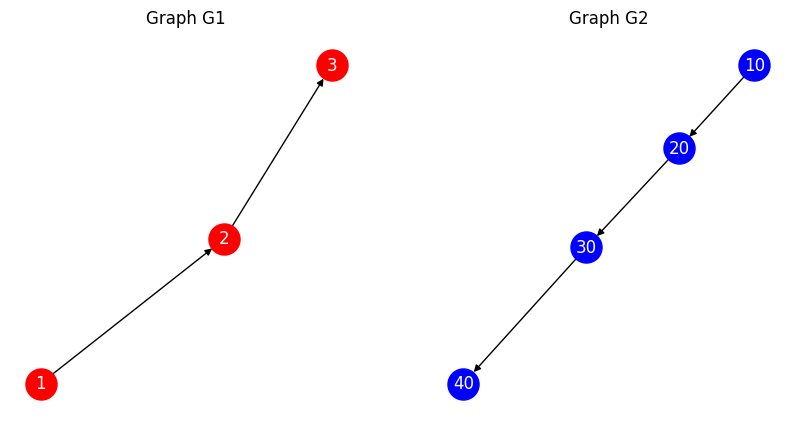

In [ ]:
# Import necessary libraries
import networkx as nx
import matplotlib.pyplot as plt

# Define the graphs G1 and G2 as provided
G1 = nx.MultiDiGraph()
G2 = nx.MultiDiGraph()

# Adding nodes with attributes to G1 and G2
G1.add_nodes_from([1, 2, 3], fill="red")
G2.add_nodes_from([10, 20, 30, 40], fill="red")

# Adding paths with attributes to both graphs
nx.add_path(G1, [1, 2, 3], weight=3, linewidth=2.5)  # No node "4" in the initial list
nx.add_path(G2, [10, 20, 30, 40], weight=3)
#nx.add_path(G2, [10, 20], weight=3)
#nx.add_path(G2, [10, 20], weight=3)
#nx.add_path(G2, [10, 40], weight=3)
#nx.add_path(G2, [10, 30], weight=3)

# Set up the layout for better visualization
pos1 = nx.spring_layout(G1)  # Layout positions for G1
pos2 = nx.spring_layout(G2)  # Layout positions for G2

# Plotting G1
plt.figure(figsize=(10, 5))
plt.subplot(121)
nx.draw(
    G1, pos1, with_labels=True, node_color="red",
    edge_color="black", node_size=500, font_color="white"
)
plt.title("Graph G1")

# Plotting G2
plt.subplot(122)
nx.draw(
    G2, pos2, with_labels=True, node_color="blue",
    edge_color="black", node_size=500, font_color="white"
)
plt.title("Graph G2")

# Show plots
plt.show()


In [ ]:
"""
G1 = nx.MultiDiGraph()
G2 = nx.MultiDiGraph()
G1.add_nodes_from([1, 2, 3], fill="red")
G2.add_nodes_from([10, 20, 30, 40], fill="red")
nx.add_path(G1, [1, 2, 3, 4], weight=3, linewidth=2.5)
nx.add_path(G2, [10, 20, 30, 40], weight=3)
"""
nm = iso.categorical_node_match("fill", "red")
nx.is_isomorphic(G1, G2, node_match=nm)

False

## pygmtools implementation attempt

In [ ]:
pip install pygmtools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 790.3/790.3 kB 10.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pygmtools as pygm
import itertools
import time
pygm.set_backend('numpy')
np.random.seed(1)

In [ ]:
#We need:
# (mxnxn) adjacency matrix,
# (mxmxnxn) multi-matching permutation matrix when no of graphs is more than 2.
# node_feat_dim:  number of node feature dimensions

# m = no of graphs
# n = no of nodes

In [ ]:
# Generate isomorphic graphs
graph_num = 10
# m = no of graphs
# n = no of nodes
#As = adjacency matrix, dim = (mxnxn)
#X_gt = permutation matrix, dim = (mxmxnxn)
#Fs = Features matrix, dim = (m x n x feature dimensions)
As, X_gt, Fs = pygm.utils.generate_isomorphic_graphs(node_num=4, graph_num=10, node_feat_dim=10)

In [ ]:
# Compute node-wise similarity by inner-product and Sinkhorn
W = np.matmul(np.expand_dims(Fs,axis=1), np.expand_dims(Fs.swapaxes(1, 2),axis=0))
W = pygm.sinkhorn(W.reshape(graph_num ** 2, 4, 4)).reshape(graph_num, graph_num, 4, 4)

In [ ]:
# Solve the multi-matching problem
X = pygm.gamgm(As, W)
matched = 0
for i, j in itertools.product(range(graph_num), repeat=2):
   matched += (X[i,j] * X_gt[i,j]).sum()
acc = matched / X_gt.sum()
acc

1.0

In [ ]:
# This function supports graphs with different nodes (also known as partial matching)
# In the following we ignore the last node from the last 5 graphs
ns = np.array([4, 4, 4, 4, 4, 3, 3, 3, 3, 3], dtype='i4')
for i in range(graph_num):
   As[i, ns[i]:, :] = 0
   As[i, :, ns[i]:] = 0

for i, j in itertools.product(range(graph_num), repeat=2):
   X_gt[i, j, ns[i]:, :] = 0
   X_gt[i, j, :, ns[j]:] = 0
   W[i, j, ns[i]:, :] = 0
   W[i, j, :, ns[j]:] = 0

In [ ]:
# Partial matching is challenging and the following parameters are carefully tuned
X = pygm.gamgm(As, W, ns, n_univ=4, sk_init_tau=.1, sk_min_tau=0.01, param_lambda=0.3)

In [ ]:
# Check the partial matching result
matched = 0
for i, j in itertools.product(range(graph_num), repeat=2):
   matched += (X[i,j] * X_gt[i, j, :ns[i], :ns[j]]).sum()
matched / X_gt.sum()

0.5394321766561514

In [ ]:
network_listx

In [ ]:
for x in network_listx:
  print(x)

MultiDiGraph with 19 nodes and 31 edges


In [ ]:
import networkx as nx

# Assuming network_listx is a list containing a MultiDiGraph
network = network_listx[0]

# Get nodes
nodes = list(network.nodes)

# Get edges
edges = list(network.edges)

# Print nodes and edges
print("Nodes:", nodes)
print("Edges:", edges)


Nodes: ['Die Frau', 'Der Wind', 'Namenloser Erzähler1', 'die Straße', 'der Alte', 'aufflammende Straßenlaternen', 'sein Gesicht', 'ihre Stimme', 'ihre Erklärung', 'Eine Menschenmenge', 'Die Polizisten', 'ein kleiner Knabe', 'Autor', 'den Wachleuten', 'ihr eigenes finsteres Fenster', 'dieses Licht', 'des Überfallautos', 'Fenster', 'eines der erleuchteten Fenster']
Edges: [('Die Frau', 'Der Wind', 0), ('Die Frau', 'die Straße', 0), ('Die Frau', 'Die Frau', 0), ('Die Frau', 'der Alte', 0), ('Die Frau', 'der Alte', 1), ('Die Frau', 'der Alte', 2), ('Die Frau', 'ein kleiner Knabe', 0), ('Namenloser Erzähler1', 'Die Frau', 0), ('Namenloser Erzähler1', 'Die Frau', 1), ('Namenloser Erzähler1', 'Die Frau', 2), ('Namenloser Erzähler1', 'Die Frau', 3), ('Namenloser Erzähler1', 'Die Frau', 4), ('Namenloser Erzähler1', 'der Alte', 0), ('Namenloser Erzähler1', 'der Alte', 1), ('Namenloser Erzähler1', 'der Alte', 2), ('Namenloser Erzähler1', 'der Alte', 3), ('Namenloser Erzähler1', 'der Alte', 4), ('

In [ ]:
import networkx as nx

# Assuming network_listx is a list containing a MultiDiGraph
network = network_listx[0]

# Get nodes
nodes = list(network.nodes)

# Get edges
edges = list(network.edges(data=True)) #source node, target node,  edge:(label, weight,edge_type)

# Print nodes and edges
print("Nodes:", nodes)
print("Edges:", edges)

Nodes: ['Die Frau', 'Der Wind', 'Namenloser Erzähler1', 'die Straße', 'der Alte', 'aufflammende Straßenlaternen', 'sein Gesicht', 'ihre Stimme', 'ihre Erklärung', 'Eine Menschenmenge', 'Die Polizisten', 'ein kleiner Knabe', 'Autor', 'den Wachleuten', 'ihr eigenes finsteres Fenster', 'dieses Licht', 'des Überfallautos', 'Fenster', 'eines der erleuchteten Fenster']
Edges: [('Die Frau', 'Der Wind', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'}), ('Die Frau', 'die Straße', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'}), ('Die Frau', 'Die Frau', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'}), ('Die Frau', 'der Alte', {'label': 'sonstige', 'weight': -1, 'edge_type': 'evaluation'}), ('Die Frau', 'der Alte', {'label': 'Sonstige Merkmalsopposition', 'edge_type': 'opposition'}), ('Die Frau', 'der Alte', {'label': 'Traditionell-Modern-Opposition', 'edge_type': 'opposition'}), ('Die Frau', 'ein kleiner Knabe', {'label': 'Sonstige Merkmalsoppositio